# Tải các package cần thiết

In [2]:
!pip uninstall numpy pmdarima pandas scikit-learn matplotlib seaborn xgboost thinc spacy -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: matplotlib 3.10.0
Uninstalling matplotlib-3.10.0:
  Successfully uninstalled matplotlib-3.10.0
Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2
Found existing installation: xgboost 2.1.4
Uninstalling xgboost-2.1.4:
  Successfully uninstalled xgboost-2.1.4
Found existing installation: thinc 8.3.6
Uninstalling thinc-8.3.6:
  Successfully uninstalled thinc-8.3.6
Found existing installation: spacy 3.8.5
Uninstalling spacy-3.8.5:
  Successfully uninstalled spacy-3.8.5


In [3]:
!pip install --no-cache-dir numpy==1.26.4
!pip install --no-cache-dir pmdarima==2.0.4
!pip install --no-cache-dir pandas scikit-learn matplotlib seaborn xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 93.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wordcloud 1.9.4 requires matplotlib, which is not installed.
dask-cuda 25.2.0 requires pandas>=1.3, which is not installed.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, which is not installed.
geopandas 1.0.1 requires pandas>=1.4.0, which is not installed.
yfinance 0.2.55 requires pandas>=1.3.0, which is not installed.
fastai 2.7.19 requires matplotlib, which is not installed.
fastai 2.7.19 requires pandas, which is not installed.
fastai 2.7.19 requires scikit-learn, which is not installed.
fastai 2.7.19 requires spacy<4, which is not installed.
pycocotools 2.0.8 requires matplotlib>=2.1.0, which is not installed.
cudf-cu12 25.2.1 requires pandas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

import pandas as pd
import numpy as np
import re
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import calendar
# from pmdarima import auto_arima
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb # Import XGBoost

import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1: Nạp data

In [5]:
try:
    df = pd.read_csv('50_sample_data.csv')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('50_sample_data.csv', encoding='latin1')
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        exit()

df.columns = df.columns.str.strip()

print("--- Thông tin cơ bản về dữ liệu ---")
df.info()

--- Thông tin cơ bản về dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 26 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                

## 1.1 Thống kê mô tả cho các cột số

In [6]:
print("\n--- Thống kê mô tả cho các cột số ---")
numeric_cols = df.select_dtypes(include=np.number).columns
print(df[numeric_cols].describe())


--- Thống kê mô tả cho các cột số ---
       Restaurant ID      Order ID      Distance  Bill subtotal  \
count   2.132100e+04  2.132100e+04  21321.000000   21321.000000   
mean    2.074413e+07  6.354622e+09      4.167511     750.076838   
std     2.447193e+05  1.230263e+08      2.994672     498.759428   
min     2.032061e+07  6.086767e+09      0.500000      50.000000   
25%     2.063570e+07  6.250751e+09      2.000000     459.000000   
50%     2.065987e+07  6.357715e+09      3.000000     629.000000   
75%     2.088265e+07  6.456827e+09      6.000000     899.000000   
max     2.152306e+07  6.573392e+09     21.000000   16080.000000   

       Packaging charges  Restaurant discount (Promo)  \
count       21321.000000                 21321.000000   
mean           32.564592                    65.091816   
std            22.235898                    85.401604   
min             0.000000                     0.000000   
25%            18.450000                     0.000000   
50%            

# 2: Tiền xử lý dữ liệu (riêng cho promotion_impact)

In [7]:
# Chuẩn hóa các loại % off
def clean_discount(text):
    if isinstance(text, str):
        if '%' in text and 'off upto' in text:
            return 'Percentage Off with Cap'
        elif 'Flat' in text and 'off' in text:
            return 'Flat Off'
        elif text == 'No Discount':
            return 'No Discount'
        elif 'Buy' in text and 'Get' in text:
            return 'Buy X Get Y'
    return 'Other/Unknown'

df['Discount Category'] = df['Discount construct'].apply(clean_discount)
print("\n--- Các loại Discount Category sau khi gom nhóm ---")
print(df['Discount Category'].value_counts())


--- Các loại Discount Category sau khi gom nhóm ---
Discount Category
Flat Off                   5925
No Discount                5498
Percentage Off with Cap    5275
Buy X Get Y                4621
Other/Unknown                 2
Name: count, dtype: int64


# 3: Visualize to get insight

## 3.1: Trực quan phân tích hiệu quả kinh doanh theo từng loại khuyến mãi

--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---
Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:
         Discount Category  Số lượng đơn hàng  Tổng Doanh thu (Total)  \
1                 Flat Off               5925            5,419,492.12   
2              No Discount               5498            3,834,917.99   
4  Percentage Off with Cap               5275            2,344,646.72   
0              Buy X Get Y               4621            2,953,285.61   
3            Other/Unknown                  2                1,715.70   

   Tổng Giá trị hàng hóa (Subtotal)  Tổng Chi phí Discount  Tổng Phí Đóng gói  \
1                      6,105,667.32             944,387.79         258,212.43   
2                      4,315,604.99             664,315.55         183,628.53   
4                      2,756,828.99             523,936.63         111,754.36   
0                      2,812,652.96                   0.00         140,632.65   
3                          1,634.00                   0.0

<ipython-input-10-dd08ea4eca00>:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
<ipython-input-10-dd08ea4eca00>:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
<ipython-input-10-dd08ea4eca00>:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], x='Discount Category', y='AOV (Average Total)', data=agg_df, palette='Oranges_d')
<ipython-inp

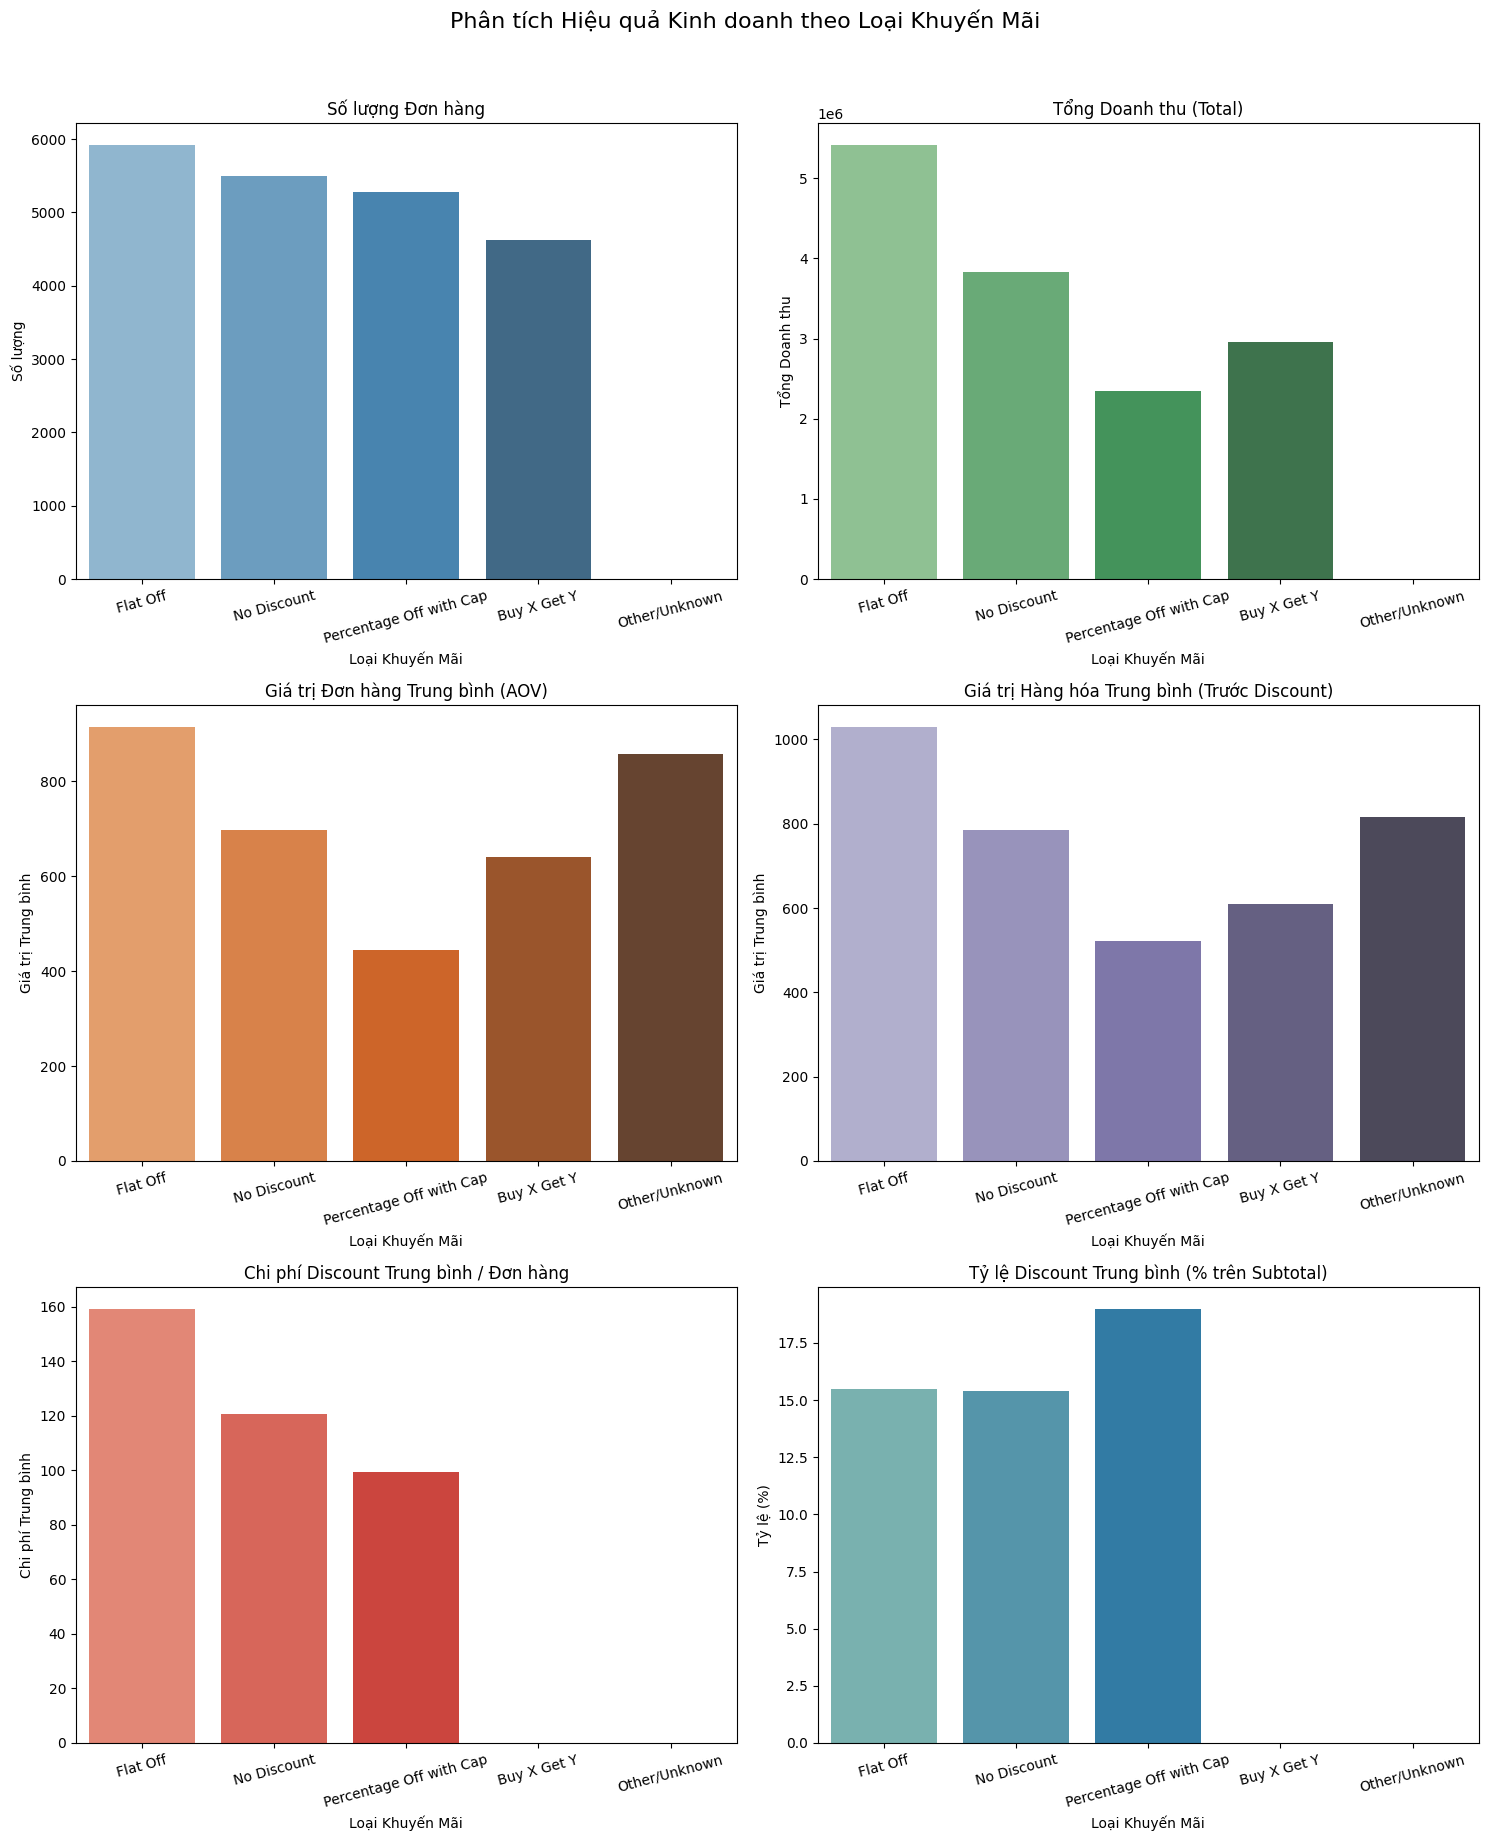

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bước 1: Tổng hợp dữ liệu theo Discount Category
print("--- Bước 1: Tổng hợp dữ liệu theo Loại Khuyến Mãi ---")

# Tính tổng chi phí giảm giá số cho mỗi đơn hàng
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]
df['Total Numerical Discount Cost'] = df[discount_cols_numeric].sum(axis=1)

# Tổng hợp dữ liệu
agg_metrics = {
    'Order ID': ('Order ID', 'count'),
    'Total': ('Total', 'sum'),
    'Bill subtotal': ('Bill subtotal', 'sum'),
    'Total Numerical Discount Cost': ('Total Numerical Discount Cost', 'sum'),
    'Packaging charges': ('Packaging charges', 'sum')
}

agg_df = df.groupby('Discount Category').agg(**agg_metrics).reset_index()

# Đổi tên cột
agg_df.rename(columns={
    'Order ID': 'Số lượng đơn hàng',
    'Total': 'Tổng Doanh thu (Total)',
    'Bill subtotal': 'Tổng Giá trị hàng hóa (Subtotal)',
    'Total Numerical Discount Cost': 'Tổng Chi phí Discount',
    'Packaging charges': 'Tổng Phí Đóng gói'
}, inplace=True)

# Tính toán các chỉ số trung bình và tỷ lệ
agg_df['AOV (Average Total)'] = agg_df['Tổng Doanh thu (Total)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Bill Subtotal'] = agg_df['Tổng Giá trị hàng hóa (Subtotal)'] / agg_df['Số lượng đơn hàng']
agg_df['Average Discount per Order'] = agg_df['Tổng Chi phí Discount'] / agg_df['Số lượng đơn hàng']
agg_df['Average Discount % (of Subtotal)'] = np.where(
    agg_df['Tổng Giá trị hàng hóa (Subtotal)'] > 0,
    (agg_df['Tổng Chi phí Discount'] / agg_df['Tổng Giá trị hàng hóa (Subtotal)']) * 100,
    0
)

# Sắp xếp theo số lượng đơn hàng
agg_df = agg_df.sort_values(by='Số lượng đơn hàng', ascending=False)

# Hiển thị bảng tổng hợp
print("Bảng tổng hợp hiệu quả theo Loại Khuyến Mãi:")
pd.options.display.float_format = '{:,.2f}'.format
print(agg_df)
print("-" * 70)

# Bước 2: Trực quan hóa kết quả tổng hợp
print("\n--- Bước 2: Trực quan hóa Hiệu quả theo Loại Khuyến Mãi ---")

# Tạo subplot
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
fig.suptitle('Phân tích Hiệu quả Kinh doanh theo Loại Khuyến Mãi', fontsize=16, y=1.02)

# 1. Số lượng đơn hàng
sns.barplot(ax=axes[0, 0], x='Discount Category', y='Số lượng đơn hàng', data=agg_df, palette='Blues_d')
axes[0, 0].set_title('Số lượng Đơn hàng')
axes[0, 0].set_xlabel('Loại Khuyến Mãi')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Tổng Doanh thu (Total)
sns.barplot(ax=axes[0, 1], x='Discount Category', y='Tổng Doanh thu (Total)', data=agg_df, palette='Greens_d')
axes[0, 1].set_title('Tổng Doanh thu (Total)')
axes[0, 1].set_xlabel('Loại Khuyến Mãi')
axes[0, 1].set_ylabel('Tổng Doanh thu')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. AOV (Average Total)
sns.barplot(ax=axes[1, 0], x='Discount Category', y='AOV (Average Total)', data=agg_df, palette='Oranges_d')
axes[1, 0].set_title('Giá trị Đơn hàng Trung bình (AOV)')
axes[1, 0].set_xlabel('Loại Khuyến Mãi')
axes[1, 0].set_ylabel('Giá trị Trung bình')
axes[1, 0].tick_params(axis='x', rotation=15)

# 4. Average Bill Subtotal
sns.barplot(ax=axes[1, 1], x='Discount Category', y='Average Bill Subtotal', data=agg_df, palette='Purples_d')
axes[1, 1].set_title('Giá trị Hàng hóa Trung bình (Trước Discount)')
axes[1, 1].set_xlabel('Loại Khuyến Mãi')
axes[1, 1].set_ylabel('Giá trị Trung bình')
axes[1, 1].tick_params(axis='x', rotation=15)

# 5. Average Discount per Order
sns.barplot(ax=axes[2, 0], x='Discount Category', y='Average Discount per Order', data=agg_df, palette='Reds_d')
axes[2, 0].set_title('Chi phí Discount Trung bình / Đơn hàng')
axes[2, 0].set_xlabel('Loại Khuyến Mãi')
axes[2, 0].set_ylabel('Chi phí Trung bình')
axes[2, 0].tick_params(axis='x', rotation=15)

# 6. Average Discount % (of Subtotal)
sns.barplot(ax=axes[2, 1], x='Discount Category', y='Average Discount % (of Subtotal)', data=agg_df, palette='YlGnBu_d')
axes[2, 1].set_title('Tỷ lệ Discount Trung bình (% trên Subtotal)')
axes[2, 1].set_xlabel('Loại Khuyến Mãi')
axes[2, 1].set_ylabel('Tỷ lệ (%)')
axes[2, 1].tick_params(axis='x', rotation=15)

# Điều chỉnh layout và hiển thị
plt.tight_layout()
plt.show()

## 3.2: Số lượng Khách hàng Khác nhau theo Loại Khuyến Mãi & Phân phối Tần suất Đặt hàng của Khách hàng


--- 3.3: Phân tích Khách hàng Cơ bản ---

Số lượng Khách hàng Khác nhau theo Loại Khuyến Mãi:
Discount Category
Flat Off                   4092
Percentage Off with Cap    3896
No Discount                3827
Buy X Get Y                3342
Other/Unknown                 1
Name: Customer ID, dtype: int64


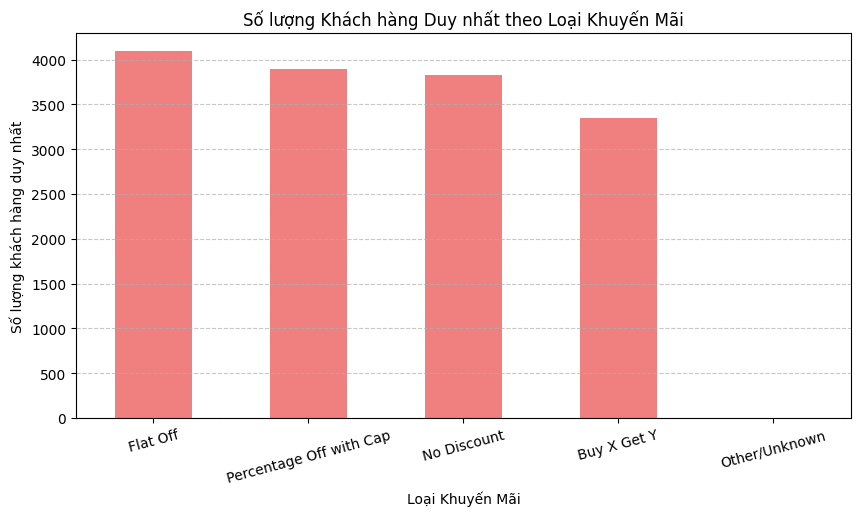


Phân phối Tần suất Đặt hàng của Khách hàng:
count   11,607.00
mean         1.84
std          2.03
min          1.00
25%          1.00
50%          1.00
75%          2.00
max         61.00
Name: count, dtype: float64


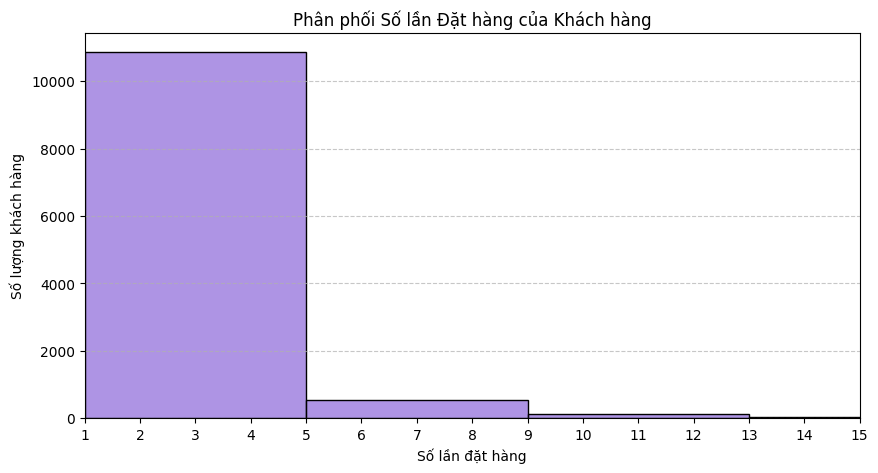


Trong tập dữ liệu này, có 11607 khách hàng khác nhau.
Khách hàng đặt nhiều đơn nhất đã đặt: 61 đơn.
Số khách hàng chỉ đặt 1 đơn: 7713.


In [11]:
# --- 3.3: Phân tích Khách hàng cơ bản ---
print("\n--- 3.3: Phân tích Khách hàng Cơ bản ---")

# Số lượng khách hàng khác nhau sử dụng từng loại khuyến mãi
customers_per_discount = df.groupby('Discount Category')['Customer ID'].nunique().sort_values(ascending=False)
print("\nSố lượng Khách hàng Khác nhau theo Loại Khuyến Mãi:")
print(customers_per_discount)

plt.figure(figsize=(10, 5))
customers_per_discount.plot(kind='bar', color='lightcoral')
plt.title('Số lượng Khách hàng Duy nhất theo Loại Khuyến Mãi')
plt.xlabel('Loại Khuyến Mãi')
plt.ylabel('Số lượng khách hàng duy nhất')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Phân tích tần suất đặt hàng của khách hàng
customer_frequency = df['Customer ID'].value_counts()
print("\nPhân phối Tần suất Đặt hàng của Khách hàng:")
print(customer_frequency.describe()) # Xem thống kê mô tả tần suất

plt.figure(figsize=(10, 5))
sns.histplot(customer_frequency, bins=15, kde=False, color='mediumpurple')
plt.title('Phân phối Số lần Đặt hàng của Khách hàng')
plt.xlabel('Số lần đặt hàng')
plt.ylabel('Số lượng khách hàng')
plt.xticks(range(1, 16))
plt.xlim(1, 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"\nTrong tập dữ liệu này, có {df['Customer ID'].nunique()} khách hàng khác nhau.")
print(f"Khách hàng đặt nhiều đơn nhất đã đặt: {customer_frequency.max()} đơn.")
print(f"Số khách hàng chỉ đặt 1 đơn: {sum(customer_frequency == 1)}.")

# 4: Phân tích ANOVA

---


- Xem xét liệu có sự khác biệt đáng kể về mặt thống kê trong giá trị trung bình của 'Total' giữa các nhóm 'Discount Category' khác nhau hay không

In [12]:
print("\nĐang tạo df_anova bằng cách lọc các category có ít nhất 2 đơn hàng...")
category_counts_full = df['Discount Category'].value_counts()
valid_categories_full = category_counts_full[category_counts_full >= 2].index.tolist()
df_anova = df[df['Discount Category'].isin(valid_categories_full)].copy()

print(f"\nTổng số dòng trong df_anova sau khi lọc: {len(df_anova)}")
print(f"Các Discount Category còn lại trong df_anova: {df_anova['Discount Category'].unique().tolist()}")

print("\n--- Thực hiện phân tích ANOVA trên 'Total' theo 'Discount Category' ---")

model_anova_total = ols('Total ~ C(Q("Discount Category"))', data=df_anova).fit()
anova_table_total = sm.stats.anova_lm(model_anova_total, typ=2)

print("\nBảng kết quả ANOVA:")
print(anova_table_total)

try:
    p_value_total = anova_table_total.loc['C(Q("Discount Category"))', 'PR(>F)']
except KeyError:
    if not anova_table_total.empty and 'PR(>F)' in anova_table_total.columns:
        p_value_total = anova_table_total.iloc[0]['PR(>F)']
    else:
        print("\nLỗi: Không tìm thấy p-value trong bảng ANOVA. Vui lòng kiểm tra cấu trúc bảng.")
        p_value_total = float('nan')

print(f"\nKết luận từ ANOVA:")
if p_value_total < 0.05:
    print(f"P-value ({p_value_total:.4f}) < 0.05.")
    print("-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa ít nhất một cặp nhóm khuyến mãi.")
else:
    print(f"P-value ({p_value_total:.4f}) >= 0.05.")
    print("-> Không có đủ bằng chứng cho thấy sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa các nhóm khuyến mãi trong tập dữ liệu này.")

print("---------------------------------------------------------------------------")



Đang tạo df_anova bằng cách lọc các category có ít nhất 2 đơn hàng...

Tổng số dòng trong df_anova sau khi lọc: 21321
Các Discount Category còn lại trong df_anova: ['Percentage Off with Cap', 'Flat Off', 'No Discount', 'Buy X Get Y', 'Other/Unknown']

--- Thực hiện phân tích ANOVA trên 'Total' theo 'Discount Category' ---

Bảng kết quả ANOVA:
                                    sum_sq        df      F  PR(>F)
C(Q("Discount Category"))   628,252,340.75      4.00 839.53    0.00
Residual                  3,987,892,176.14 21,316.00    NaN     NaN

Kết luận từ ANOVA:
P-value (0.0000) < 0.05.
-> Có sự khác biệt đáng kể về mặt thống kê trong giá trị Total TRUNG BÌNH giữa ít nhất một cặp nhóm khuyến mãi.
   Điều này củng cố quan sát từ biểu đồ boxplot rằng các nhóm có thể có AOV trung bình khác nhau.
---------------------------------------------------------------------------


# 5: Xem insight chi tiết về Per/Cap


--- Phân tích Hiệu quả và Khoảng thời gian của từng Loại KM Percentage Off cụ thể ---

Đang phân tích các loại khuyến mãi cụ thể trong nhóm 'Percentage Off with Cap'.

Bảng tổng hợp hiệu quả và khoảng thời gian của các loại KM 'Percentage Off with Cap':
    Discount construct First_Order_Date_Str Last_Order_Date_Str  Total_Orders  \
3  50% off upto Rs.100           2024-09-01          2025-01-31          3561   
4  60% off upto Rs.120           2024-09-01          2025-01-31          1102   
2   40% off upto Rs.80           2024-09-01          2024-11-29           572   
0   20% off upto Rs.50           2024-09-01          2024-10-27            34   
1   30% off upto Rs.75           2024-09-21          2024-12-14             6   

   Total_Discount_Cost  Total_Revenue  Average_Bill_Subtotal  \
3            364829.08     1706631.46                 558.86   
4            110281.69      397779.68                 443.85   
2             46200.40      223940.83                 453.60   
0 

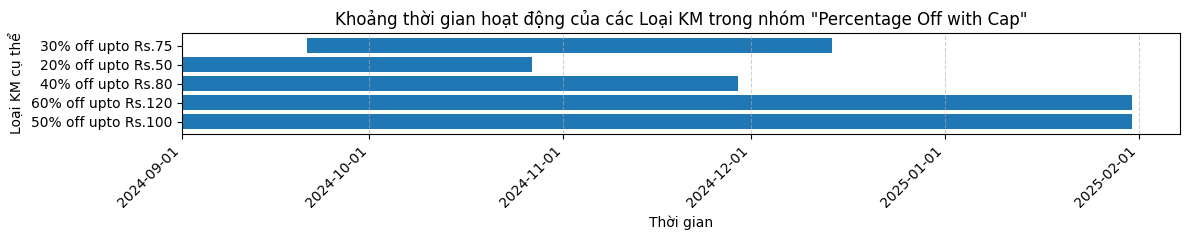


Giải thích Biểu đồ Khoảng thời gian:
- Mỗi thanh ngang biểu thị một loại KM cụ thể trong nhóm 'Percentage Off with Cap'.
- Chiều dài của thanh thể hiện khoảng thời gian từ đơn hàng đầu tiên đến đơn hàng cuối cùng sử dụng loại KM đó.
----------------------------------------------------------------------

--- Phân tích Tương quan của Percentage/Cap với Doanh thu và Chi phí ---

Ma trận tương quan:
                               Percentage   Cap  Total  \
Percentage                           1.00  1.00  -0.07   
Cap                                  1.00  1.00  -0.07   
Total                               -0.07 -0.07   1.00   
Total Numerical Discount Cost        0.14  0.14   0.14   

                               Total Numerical Discount Cost  
Percentage                                              0.14  
Cap                                                     0.14  
Total                                                   0.14  
Total Numerical Discount Cost                           1

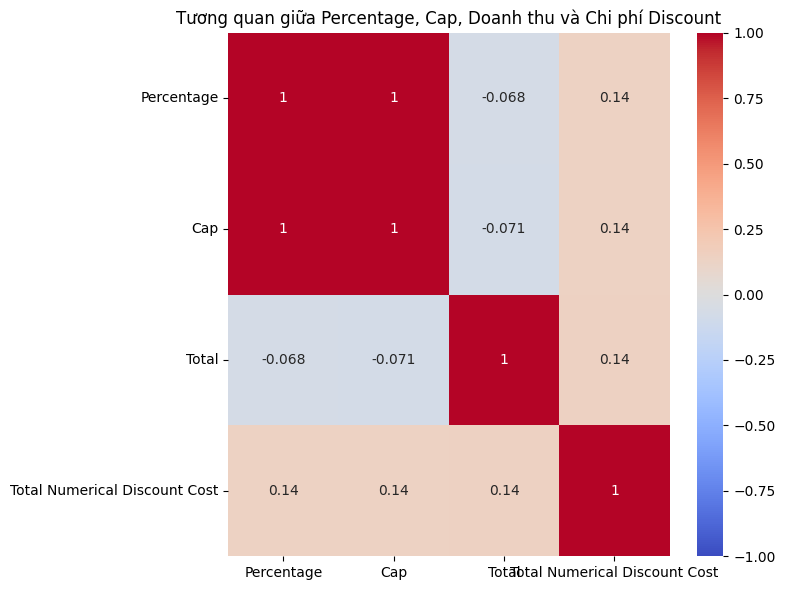

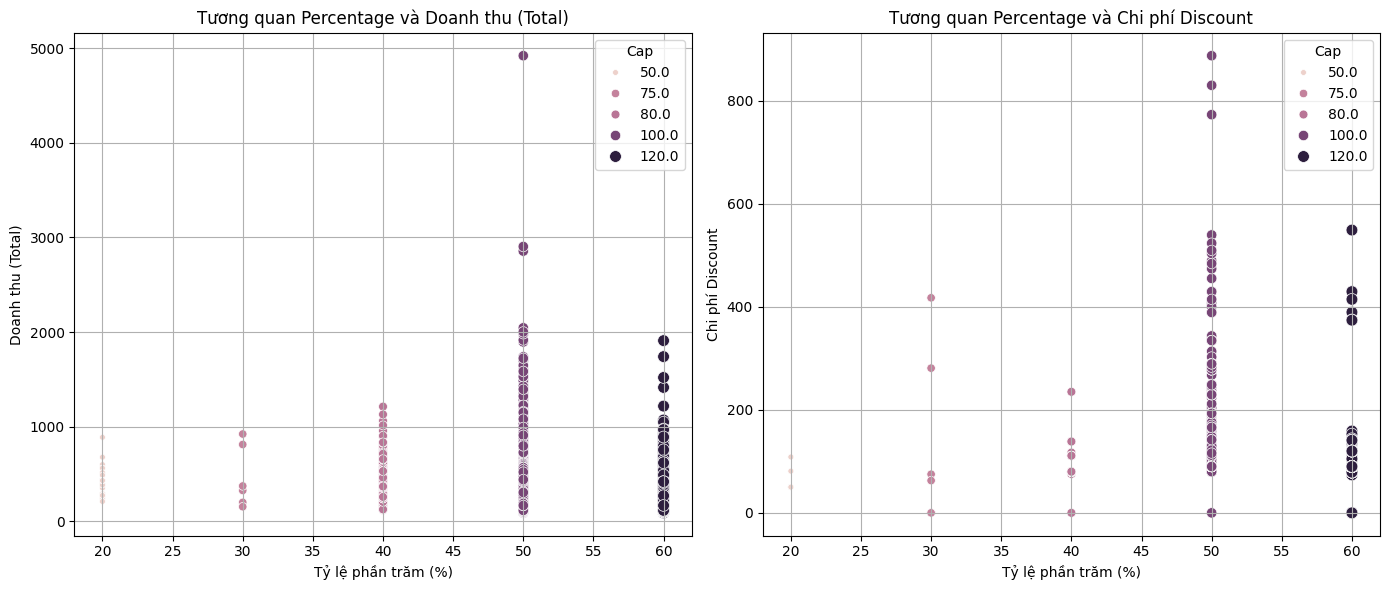


Giải thích Tương quan:
- Ma trận tương quan cho thấy mức độ liên quan giữa Percentage, Cap, Doanh thu và Chi phí.
- Scatter plot hiển thị cách Percentage ảnh hưởng đến Doanh thu/Chi phí, với kích thước và màu sắc biểu thị Cap.
- Nếu tương quan gần 1 hoặc -1, mối quan hệ mạnh; gần 0 thì yếu.
----------------------------------------------------------------------

--- Phân tích Bill Subtotal theo Loại KM Percentage Off with Cap ---


<ipython-input-28-189d35d4d4b6>:164: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_target_category, x='Bill subtotal', y='Discount construct', palette='Set2')


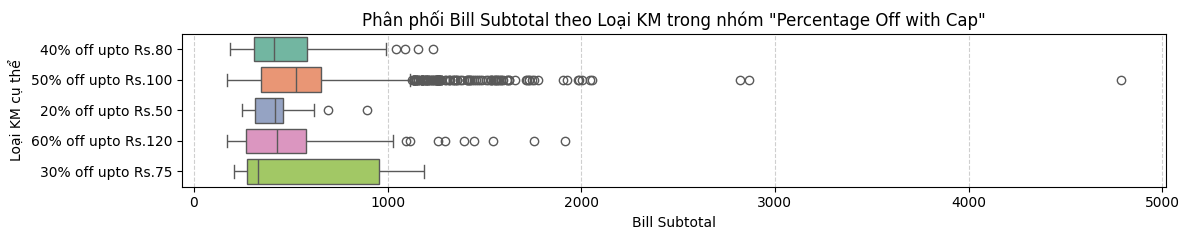


Giải thích Biểu đồ Bill Subtotal:
- Boxplot cho thấy phân phối Bill Subtotal cho từng loại KM cụ thể.
- Hộp (box) biểu thị khoảng từ Q1 đến Q3 (50% dữ liệu trung tâm).
- Đường giữa hộp là giá trị trung vị (median) của Bill Subtotal.
- Các điểm ngoài cùng (whiskers) cho thấy phạm vi dữ liệu, ngoại trừ các giá trị ngoại lai (outliers).
- Điều này giúp bạn thấy loại KM nào thường được dùng với đơn hàng có Bill Subtotal cao/thấp.
----------------------------------------------------------------------


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import re

# Giả định df đã được tải và tiền xử lý cơ bản
if 'DayofWeek' not in df.columns:
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    df.dropna(subset=['Order Placed At'], inplace=True)
    df['DayofWeek'] = df['Order Placed At'].dt.dayofweek
    df['DayofWeekName'] = df['Order Placed At'].dt.day_name()

# Đảm bảo cột 'Total Numerical Discount Cost' đã được tính
discount_cols_numeric = [
    'Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'Gold discount',
    'Brand pack discount'
]
valid_cols = [col for col in discount_cols_numeric if col in df.columns]
if valid_cols:
    df['Total Numerical Discount Cost'] = df[valid_cols].sum(axis=1)
else:
    print("Cảnh báo: Không tìm thấy cột discount số nào để tính 'Total Numerical Discount Cost'. Tạo cột với giá trị 0.")
    df['Total Numerical Discount Cost'] = 0

# Đảm bảo cột 'Order Placed At' và 'Order Date'
if not pd.api.types.is_datetime64_any_dtype(df['Order Placed At']):
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    df.dropna(subset=['Order Placed At'], inplace=True)

if 'Order Date' not in df.columns:
    df['Order Date'] = df['Order Placed At'].dt.date
    df['Order Date'] = pd.to_datetime(df['Order Date'])

# --- Phân tích Hiệu quả và Khoảng thời gian của từng Loại KM Percentage Off cụ thể ---
print("\n--- Phân tích Hiệu quả và Khoảng thời gian của từng Loại KM Percentage Off cụ thể ---")

target_promo_category = 'Percentage Off with Cap'
df_target_category = df[df['Discount Category'] == target_promo_category].copy()

if df_target_category.empty:
    print(f"Không tìm thấy dữ liệu cho nhóm khuyến mãi '{target_promo_category}' trong tập dữ liệu.")
else:
    print(f"\nĐang phân tích các loại khuyến mãi cụ thể trong nhóm '{target_promo_category}'.")

    # Hàm trích xuất Percentage và Cap từ Discount construct
    def extract_percentage_cap(discount_str):
        try:
            # Ví dụ: "40% off upto Rs.80" -> Percentage = 40, Cap = 80
            percentage_match = re.search(r'(\d+)%', discount_str)
            cap_match = re.search(r'upto Rs\.(\d+)', discount_str)
            percentage = float(percentage_match.group(1)) if percentage_match else np.nan
            cap = float(cap_match.group(1)) if cap_match else np.nan
            return percentage, cap
        except:
            return np.nan, np.nan

    # Áp dụng hàm để tạo cột Percentage và Cap
    df_target_category[['Percentage', 'Cap']] = df_target_category['Discount construct'].apply(
        lambda x: pd.Series(extract_percentage_cap(x))
    )

    # 1. Tổng hợp dữ liệu theo Discount construct
    promo_string_performance = df_target_category.groupby('Discount construct').agg(
        First_Order_Date=('Order Date', 'min'),
        Last_Order_Date=('Order Date', 'max'),
        Total_Orders=('Order ID', 'count'),
        Total_Discount_Cost=('Total Numerical Discount Cost', 'sum'),
        Total_Revenue=('Total', 'sum'),
        Average_Bill_Subtotal=('Bill subtotal', 'mean'),
        Average_Percentage=('Percentage', 'mean'),
        Average_Cap=('Cap', 'mean')
    ).reset_index()

    promo_string_performance = promo_string_performance.sort_values(by='Total_Orders', ascending=False)

    print(f"\nBảng tổng hợp hiệu quả và khoảng thời gian của các loại KM '{target_promo_category}':")
    promo_string_performance['First_Order_Date_Str'] = promo_string_performance['First_Order_Date'].dt.strftime('%Y-%m-%d')
    promo_string_performance['Last_Order_Date_Str'] = promo_string_performance['Last_Order_Date'].dt.strftime('%Y-%m-%d')
    print(promo_string_performance[['Discount construct', 'First_Order_Date_Str', 'Last_Order_Date_Str', 'Total_Orders',
                                    'Total_Discount_Cost', 'Total_Revenue', 'Average_Bill_Subtotal', 'Average_Percentage',
                                    'Average_Cap']].round(2))

    print("-" * 70)

    # --- Trực quan hóa Khoảng thời gian hoạt động ---
    print("\n--- Trực quan hóa Khoảng thời gian hoạt động của từng Loại KM cụ thể ---")
    plt.figure(figsize=(12, min(len(promo_string_performance) * 0.5, 10)))
    promo_string_performance_sorted_time = promo_string_performance.sort_values(by='First_Order_Date')
    plt.barh(
        y=promo_string_performance_sorted_time['Discount construct'],
        left=promo_string_performance_sorted_time['First_Order_Date'],
        width=(promo_string_performance_sorted_time['Last_Order_Date'] - promo_string_performance_sorted_time['First_Order_Date']),
        height=0.8
    )
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Thời gian')
    plt.ylabel('Loại KM cụ thể')
    plt.title(f'Khoảng thời gian hoạt động của các Loại KM trong nhóm "{target_promo_category}"')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\nGiải thích Biểu đồ Khoảng thời gian:")
    print("- Mỗi thanh ngang biểu thị một loại KM cụ thể trong nhóm 'Percentage Off with Cap'.")
    print("- Chiều dài của thanh thể hiện khoảng thời gian từ đơn hàng đầu tiên đến đơn hàng cuối cùng sử dụng loại KM đó.")
    print("-" * 70)

    # --- Phân tích Tương quan Percentage/Cap với Doanh thu và Chi phí ---
    print("\n--- Phân tích Tương quan của Percentage/Cap với Doanh thu và Chi phí ---")

    # Loại bỏ các dòng có giá trị NaN trong Percentage hoặc Cap
    df_corr = df_target_category.dropna(subset=['Percentage', 'Cap', 'Total', 'Total Numerical Discount Cost'])

    if not df_corr.empty:
        # Tính ma trận tương quan
        corr_matrix = df_corr[['Percentage', 'Cap', 'Total', 'Total Numerical Discount Cost']].corr()

        print("\nMa trận tương quan:")
        print(corr_matrix.round(2))

        # Trực quan hóa bằng heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
        plt.title('Tương quan giữa Percentage, Cap, Doanh thu và Chi phí Discount')
        plt.tight_layout()
        plt.show()

        # Scatter plot để xem mối quan hệ chi tiết
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        sns.scatterplot(data=df_corr, x='Percentage', y='Total', size='Cap', hue='Cap', ax=axes[0])
        axes[0].set_title('Tương quan Percentage và Doanh thu (Total)')
        axes[0].set_xlabel('Tỷ lệ phần trăm (%)')
        axes[0].set_ylabel('Doanh thu (Total)')
        axes[0].grid(True)

        sns.scatterplot(data=df_corr, x='Percentage', y='Total Numerical Discount Cost', size='Cap', hue='Cap', ax=axes[1])
        axes[1].set_title('Tương quan Percentage và Chi phí Discount')
        axes[1].set_xlabel('Tỷ lệ phần trăm (%)')
        axes[1].set_ylabel('Chi phí Discount')
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

        print("\nGiải thích Tương quan:")
        print("- Ma trận tương quan cho thấy mức độ liên quan giữa Percentage, Cap, Doanh thu và Chi phí.")
        print("- Scatter plot hiển thị cách Percentage ảnh hưởng đến Doanh thu/Chi phí, với kích thước và màu sắc biểu thị Cap.")
        print("- Nếu tương quan gần 1 hoặc -1, mối quan hệ mạnh; gần 0 thì yếu.")
    else:
        print("Không đủ dữ liệu để tính tương quan (có giá trị NaN trong Percentage hoặc Cap).")

    print("-" * 70)

    # --- Phân tích Bill Subtotal theo Discount Construct ---
    print("\n--- Phân tích Bill Subtotal theo Loại KM Percentage Off with Cap ---")

    plt.figure(figsize=(12, min(len(promo_string_performance) * 0.5, 10)))
    sns.boxplot(data=df_target_category, x='Bill subtotal', y='Discount construct', palette='Set2')
    plt.title(f'Phân phối Bill Subtotal theo Loại KM trong nhóm "{target_promo_category}"')
    plt.xlabel('Bill Subtotal')
    plt.ylabel('Loại KM cụ thể')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\nGiải thích Biểu đồ Bill Subtotal:")
    print("- Boxplot cho thấy phân phối Bill Subtotal cho từng loại KM cụ thể.")
    print("- Hộp (box) biểu thị khoảng từ Q1 đến Q3 (50% dữ liệu trung tâm).")
    print("- Đường giữa hộp là giá trị trung vị (median) của Bill Subtotal.")
    print("- Các điểm ngoài cùng (whiskers) cho thấy phạm vi dữ liệu, ngoại trừ các giá trị ngoại lai (outliers).")
    print("- Điều này giúp bạn thấy loại KM nào thường được dùng với đơn hàng có Bill Subtotal cao/thấp.")

print("-" * 70)

# 6: Kết thúc, có Elasticity

--- BẮT ĐẦU PHÂN TÍCH ẢNH HƯỞNG CỦA KHUYẾN MÃI (TẬP TRUNG VÀO ĐƠN HÀNG SUBTOTAL > 1000) ---

--- Nạp Dữ liệu ---
Dữ liệu đã được nạp thành công. Số lượng đơn hàng ban đầu: 21321

--- Chuẩn bị Dữ liệu và Tạo Đặc trưng ---
Đã chuyển 'Order Placed At' sang datetime.
Đã tạo cột 'DayofWeek' và 'DayofWeekName'.
Đã tạo cột 'Hour'.
Đã tạo cột 'Order Date'.
Đã tạo cột 'Discount Category'.
Đã tính 'Total Numerical Discount Cost'.
Đã tạo các cột 'Discount_Pct', 'Discount_Cap', 'Discount_Flat'.
Đã tạo cột 'Num_Distinct_Items'.
----------------------------------------------------------------------

--- Huấn luyện Mô hình Regression dự đoán Bill Subtotal ---
Kích thước features_regression sau loại bỏ NaN cho Regression: (21321, 8)
Kích thước target_regression sau loại bỏ NaN cho Regression: (21321,)
Kiểm tra NaN cuối cùng: Không còn giá trị thiếu trong features_regression.

Kiểm tra cột phân loại cho OneHotEncoder...
Cột 'Discount Category' có 5 giá trị duy nhất. Giữ lại cho OHE.
Cột 'DayofWeek' có 

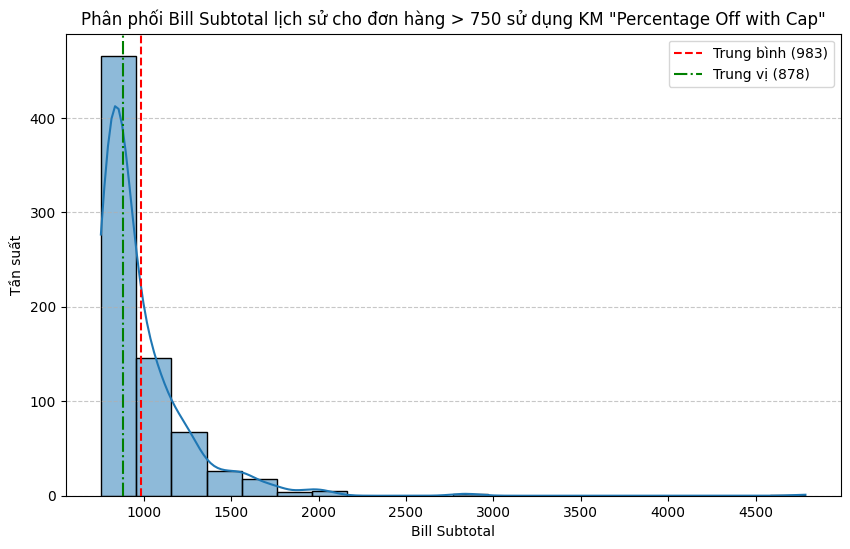


Nhận xét về Bill Subtotal lịch sử cho phân khúc này:
- Biểu đồ trên cho thấy phân phối giá trị Bill Subtotal của các đơn hàng > 750 trong lịch sử có sử dụng KM 'Percentage Off with Cap'.
- Giá trị Bill Subtotal trung bình lịch sử (983.22) được sử dụng làm giá trị giỏ hàng đại diện trong các tính toán mô phỏng hiệu quả cho 7 ngày tới.
- Điều này có nghĩa là chúng ta giả định MỖI đơn hàng trong ước tính của phân khúc này trong 7 ngày tới sẽ có Bill Subtotal bằng 983.22.
- Sự phân tán của Bill Subtotal trong lịch sử cho thấy rằng việc chỉ sử dụng giá trị trung bình là một sự đơn giản hóa.
----------------------------------------------------------------------

--- Mô phỏng Nhiều Kịch bản Percentage/Cap ---
Sử dụng Bill Subtotal trung bình lịch sử (983.22) làm giá trị đại diện cho đơn hàng > 750 sử dụng KM này.
Đang khám phá lưới 6 Percentage Rate và 12 Cap Amount (72 kịch bản).

Cặp KM Cơ sở cho tính Co giãn: 40% off upto 80 Rs.
  Discount Cost trung bình ước tính cho cặp cơ sở: 80.00 Rs.

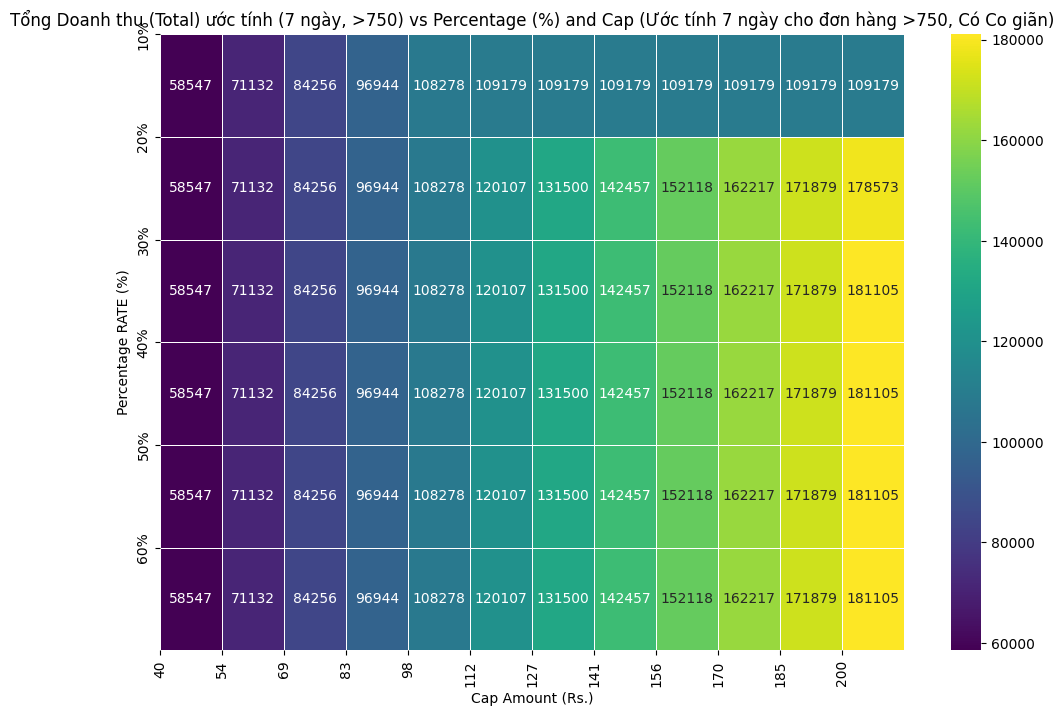


Đang vẽ heatmap cho: Tổng Chi phí Discount ước tính (7 ngày, >750)


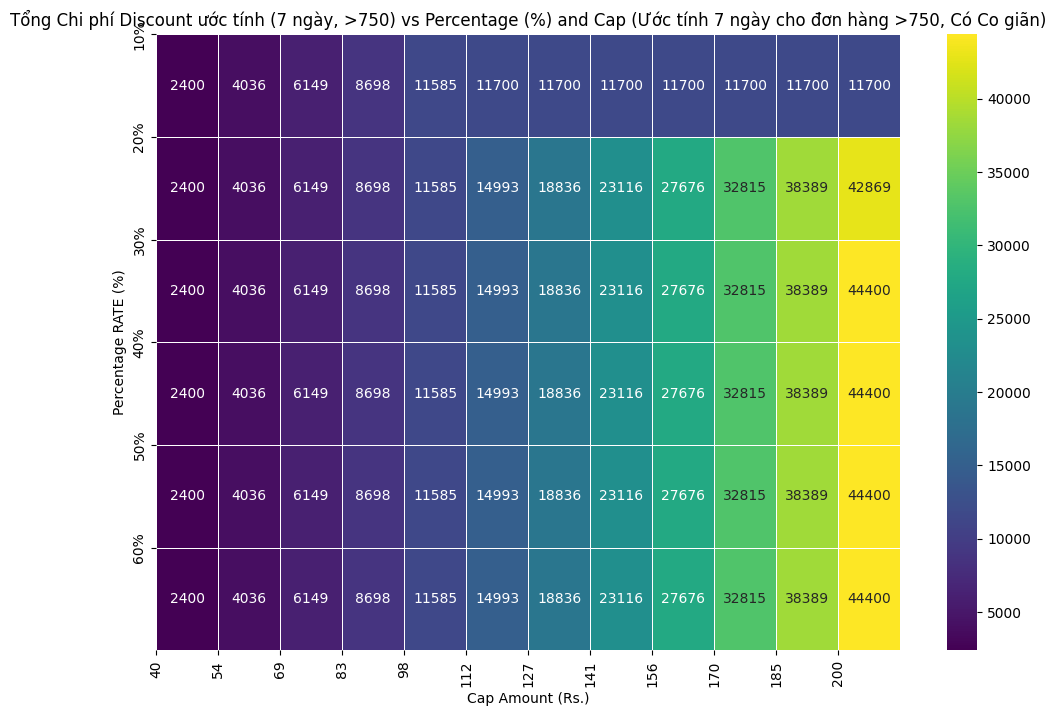


Đang vẽ heatmap cho: Revenue_per_Discount_Cost


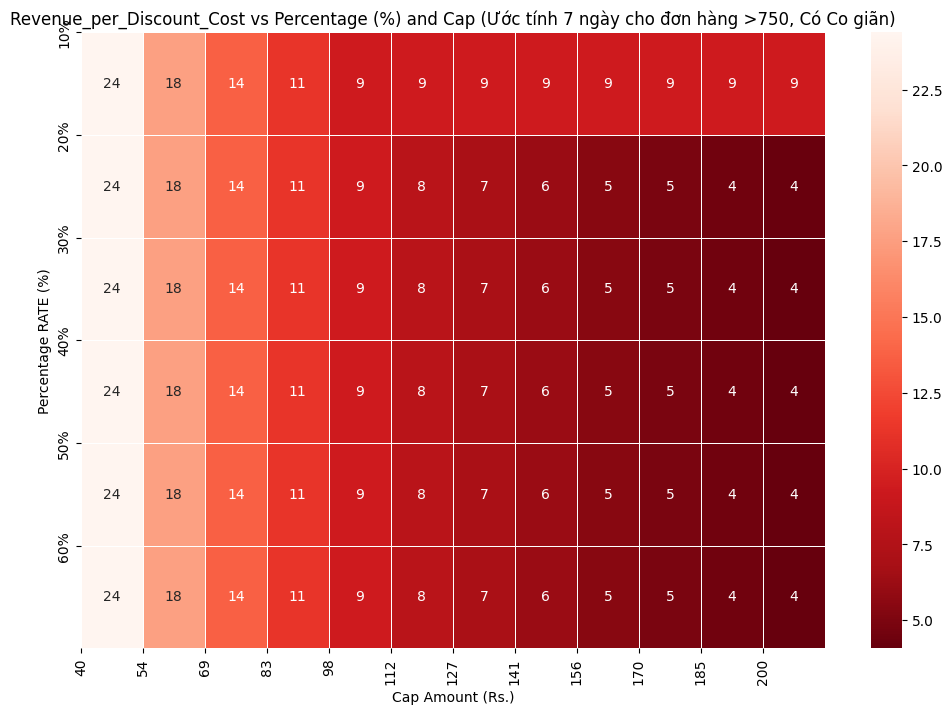


Đang vẽ heatmap cho: Số đơn dự kiến (7 ngày, >750, dùng KM này)


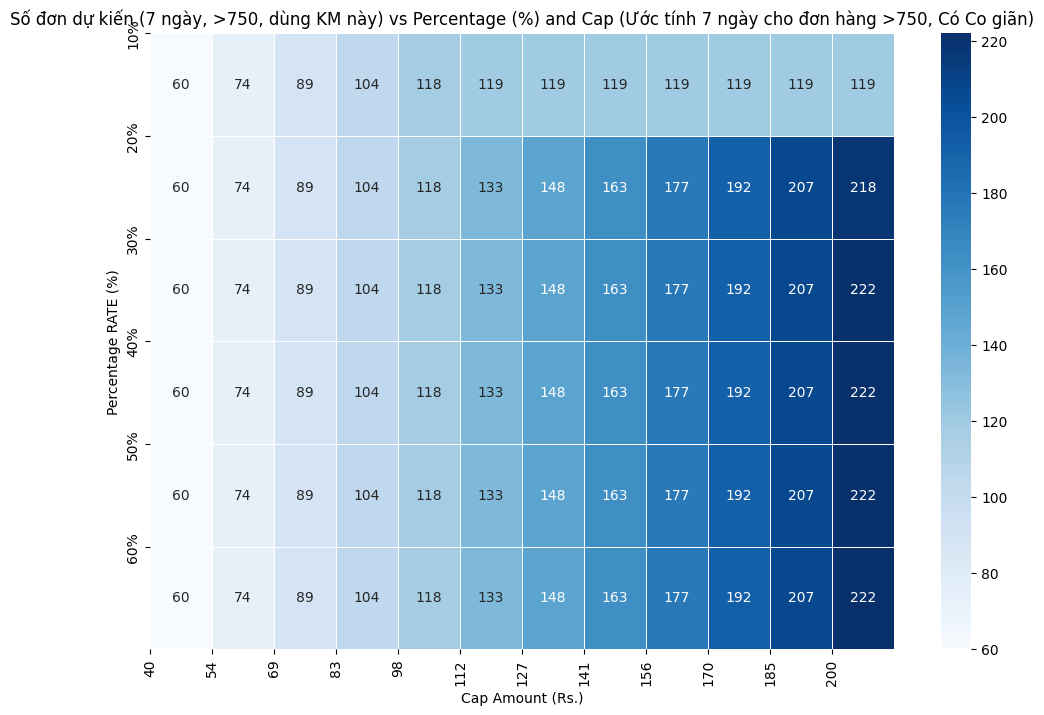


Đang vẽ heatmap cho: Pct_Change_Orders_Est


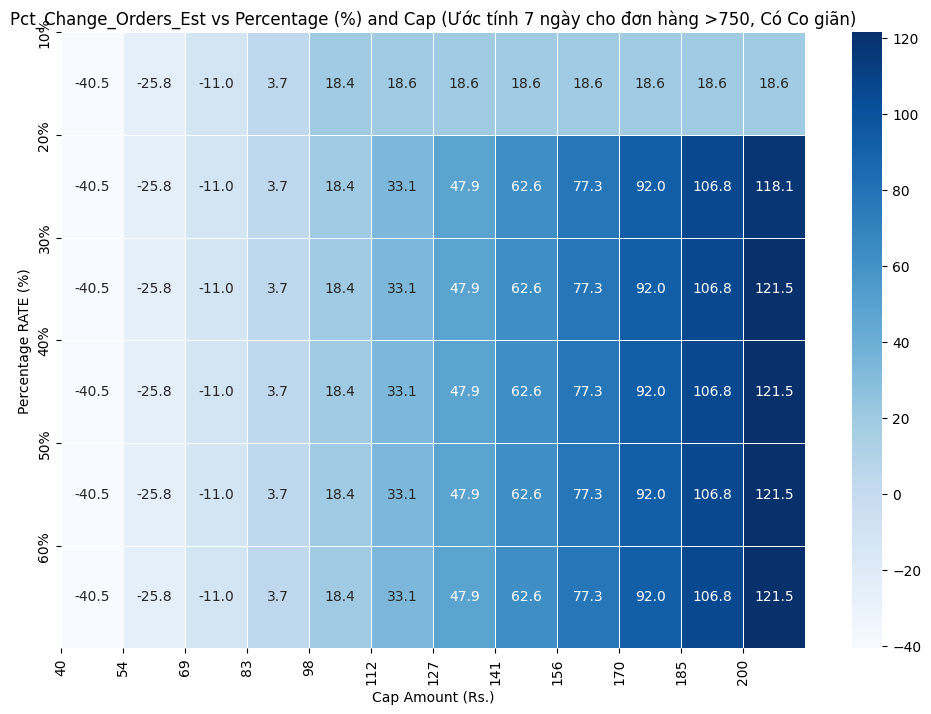


Đang vẽ heatmap cho: Estimated_Avg_Discount_Per_Order


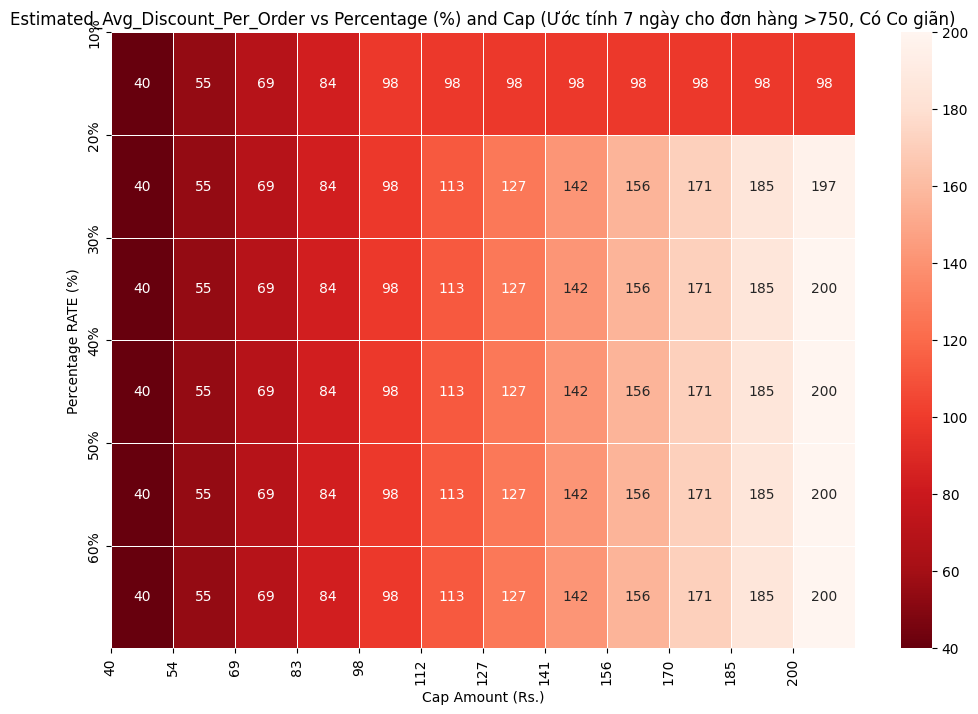


--- Nhận định chung về Kết quả Mô phỏng ---
- Các Heatmap này thể hiện các chỉ số hiệu quả dự kiến cho 7 ngày tới, CHỈ ÁP DỤNG cho nhóm đơn hàng có Bill Subtotal > 750 VÀ sử dụng loại KM 'Percentage Off with Cap', CÓ TÍNH ĐẾN CO GIÃN SỐ ĐƠN HÀNG dựa trên sự thay đổi tỷ lệ giảm giá so với cặp cơ sở (40% off upto 80 Rs.).
- Giá trị Bill Subtotal trung bình lịch sử cho phân khúc này (983.22 Rs.) được sử dụng làm giá trị giỏ hàng đại diện trong mô phỏng.
- Heatmap 'Pct_Change_Orders_Est' và 'Số đơn dự kiến': Cho thấy số lượng đơn hàng dự kiến tăng/giảm như thế nào khi KM hấp dẫn hơn/kém hơn cặp cơ sở.
- Heatmap 'Estimated_Avg_Discount_Per_Order': Cho thấy chi phí discount trung bình trên mỗi đơn hàng tăng/giảm như thế nào.
- Heatmap 'Tổng Doanh thu (Total) ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và doanh thu trên mỗi đơn hàng.
- Heatmap 'Tổng Chi phí Discount ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và chi phí discount trên mỗi đơn hàng.
- Heatmap 'Rev

In [45]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import calendar
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# --- BẮT ĐẦU PHÂN TÍCH ---
print("--- BẮT ĐẦU PHÂN TÍCH ẢNH HƯỞNG CỦA KHUYẾN MÃI (TẬP TRUNG VÀO ĐƠN HÀNG SUBTOTAL > 1000) ---")

# --- Nạp Data ---
print("\n--- Nạp Dữ liệu ---")
try:
    df = pd.read_csv('50_sample_data.csv')
except UnicodeDecodeError:
    try:
        df = pd.read_csv('50_sample_data.csv', encoding='latin1')
    except Exception as e:
        print(f"Lỗi khi đọc file CSV: {e}")
        df = pd.DataFrame()

if not df.empty:
    df.columns = df.columns.str.strip()
    print(f"Dữ liệu đã được nạp thành công. Số lượng đơn hàng ban đầu: {len(df)}")
else:
    print("Không nạp được dữ liệu. Dừng phân tích.")

# --- Chuẩn bị dữ liệu và Tạo Đặc trưng ---
print("\n--- Chuẩn bị Dữ liệu và Tạo Đặc trưng ---")
if not df.empty:
    if 'Order Placed At' in df.columns:
        if not pd.api.types.is_datetime64_any_dtype(df['Order Placed At']):
            df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
            print("Đã chuyển 'Order Placed At' sang datetime.")
        else:
            print("'Order Placed At' đã là datetime.")
        if 'DayofWeek' not in df.columns and not df['Order Placed At'].isnull().all():
            df['DayofWeek'] = df['Order Placed At'].dt.dayofweek
            df['DayofWeekName'] = df['Order Placed At'].dt.day_name()
            print("Đã tạo cột 'DayofWeek' và 'DayofWeekName'.")
        if 'Hour' not in df.columns and not df['Order Placed At'].isnull().all():
            df['Hour'] = df['Order Placed At'].dt.hour
            print("Đã tạo cột 'Hour'.")
        if 'Order Date' not in df.columns and not df['Order Placed At'].isnull().all():
            df['Order Date'] = df['Order Placed At'].dt.date
            df['Order Date'] = pd.to_datetime(df['Order Date'])
            print("Đã tạo cột 'Order Date'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Order Placed At'. Bỏ qua tạo đặc trưng thời gian.")

    def clean_discount(text):
        if isinstance(text, str):
            text = text.strip().lower()
            if '%' in text and 'off upto' in text:
                return 'Percentage Off with Cap'
            elif 'flat' in text and 'off' in text:
                return 'Flat Off'
            elif text == 'no discount':
                return 'No Discount'
            elif 'buy' in text and 'get' in text:
                return 'Buy X Get Y'
        return 'Other/Unknown'

    if 'Discount construct' in df.columns:
        df['Discount Category'] = df['Discount construct'].apply(clean_discount)
        print("Đã tạo cột 'Discount Category'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Discount construct'. Không thể tạo 'Discount Category'.")
        df['Discount Category'] = 'Unknown'

    discount_cols_numeric = [
        'Restaurant discount (Promo)',
        'Restaurant discount (Flat offs, Freebies & others)',
        'Gold discount',
        'Brand pack discount'
    ]
    valid_cols = [col for col in df.columns if col in discount_cols_numeric]
    if valid_cols:
        for col in valid_cols:
            if col in df.columns and df[col].isnull().any():
                df[col] = df[col].fillna(0)
        df['Total Numerical Discount Cost'] = df[valid_cols].sum(axis=1)
        print("Đã tính 'Total Numerical Discount Cost'.")
    else:
        print("Cảnh báo: Không tìm thấy cột discount số nào để tính 'Total Numerical Discount Cost'. Tạo cột với giá trị 0.")
        df['Total Numerical Discount Cost'] = 0

    def parse_discount_string_fixed(discount_str):
        if not isinstance(discount_str, str):
            return 0.0, 0.0, 0.0
        discount_str = discount_str.strip().lower()
        percentage = 0.0
        cap = 0.0
        flat = 0.0
        if 'upto' in discount_str and '%' in discount_str:
            pct_cap_match = re.search(r'(\d+)% off upto rs\.?([\d\.]+)', discount_str)
            if pct_cap_match:
                try:
                    percentage = float(pct_cap_match.group(1)) / 100.0
                    cap = float(pct_cap_match.group(2))
                    return percentage, cap, 0.0
                except ValueError:
                    pass
        if 'flat' in discount_str and 'off' in discount_str:
            flat_match = re.search(r'flat rs\.?([\d\.]+)\s*off', discount_str)
            if flat_match:
                try:
                    flat = float(flat_match.group(1))
                    return 0.0, 0.0, flat
                except ValueError:
                    pass
        return 0.0, 0.0, 0.0

    if 'Discount construct' in df.columns:
        df[['Discount_Pct', 'Discount_Cap', 'Discount_Flat']] = df['Discount construct'].apply(
            lambda x: pd.Series(parse_discount_string_fixed(x))
        )
        print("Đã tạo các cột 'Discount_Pct', 'Discount_Cap', 'Discount_Flat'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Discount construct'. Không thể tạo 'Discount_Pct', 'Discount_Cap', 'Discount_Flat'. Tạo cột với giá trị 0.")
        df[['Discount_Pct', 'Discount_Cap', 'Discount_Flat']] = 0.0

    def count_items_in_order(items_str):
        if not isinstance(items_str, str):
            return 1
        stripped_str = items_str.strip()
        if not stripped_str:
            return 1
        items_list = stripped_str.split(',')
        return len(items_list)

    if 'Items in order' in df.columns:
        df['Num_Distinct_Items'] = df['Items in order'].apply(count_items_in_order)
        print("Đã tạo cột 'Num_Distinct_Items'.")
    else:
        print("Cảnh báo: Không tìm thấy cột 'Items in order'. Tạo cột 'Num_Distinct_Items' với giá trị 1.")
        df['Num_Distinct_Items'] = 1

    numeric_features_to_check = ['Bill subtotal', 'Distance', 'Packaging charges', 'Rating', 'KPT duration (minutes)', 'Rider wait time (minutes)']
    for col in numeric_features_to_check:
        if col in df.columns and df[col].isnull().any():
            if col in ['Bill subtotal', 'Distance', 'Num_Distinct_Items', 'Hour', 'Packaging charges']:
                median_val = df[col].median()
                if not pd.isna(median_val):
                    df[col] = df[col].fillna(median_val)
                    print(f"Đã điền giá trị thiếu cho '{col}' bằng median ({median_val:.2f}).")
                else:
                    default_val = 0
                    df[col] = df[col].fillna(default_val)
                    print(f"Cảnh báo: Cột '{col}' toàn bộ là NaN hoặc không tính được median. Đã điền bằng giá trị mặc định ({default_val}).")
            else:
                df[col] = df[col].fillna(0)
else:
    print("Không có dữ liệu để chuẩn bị đặc trưng.")

print("-" * 70)

# --- Huấn luyện Mô hình Regression dự đoán Bill Subtotal ---
print("\n--- Huấn luyện Mô hình Regression dự đoán Bill Subtotal ---")
model_reg_pipeline = None
if not df.empty and 'Bill subtotal' in df.columns and 'DayofWeek' in df.columns and 'Discount Category' in df.columns:
    cols_for_regression = ['Bill subtotal', 'Discount Category', 'Discount_Pct', 'Discount_Cap', 'Discount_Flat', 'DayofWeek', 'Distance', 'Num_Distinct_Items', 'Hour']
    cols_for_regression = [col for col in cols_for_regression if col in df.columns]
    df_for_reg = df[cols_for_regression].dropna().copy()
    if df_for_reg.empty:
        print("Lỗi: Không còn dòng dữ liệu nào sau khi loại bỏ NaN cho Regression. Không thể huấn luyện mô hình.")
        model_reg_pipeline = None
    else:
        target_regression = df_for_reg['Bill subtotal']
        features_regression = df_for_reg.drop(columns=['Bill subtotal'])
        print(f"Kích thước features_regression sau loại bỏ NaN cho Regression: {features_regression.shape}")
        print(f"Kích thước target_regression sau loại bỏ NaN cho Regression: {target_regression.shape}")
        nan_counts_final = features_regression.isnull().sum()
        if nan_counts_final[nan_counts_final > 0].empty:
            print("Kiểm tra NaN cuối cùng: Không còn giá trị thiếu trong features_regression.")
        else:
            print("Cảnh báo: Vẫn còn giá trị thiếu sau loại bỏ NaN cho Regression. Kiểm tra lại code tiền xử lý.")
            print(nan_counts_final[nan_counts_final > 0])
        if len(features_regression) != len(target_regression) or len(features_regression) == 0:
            print(f"Lỗi: Kích thước features ({len(features_regression)}) và target ({len(target_regression)}) không khớp hoặc rỗng. Không thể huấn luyện mô hình.")
            model_reg_pipeline = None
        else:
            categorical_features_reg = ['Discount Category', 'DayofWeek']
            categorical_features_reg = [col for col in categorical_features_reg if col in features_regression.columns]
            numerical_features_reg = [col for col in features_regression.columns if col not in categorical_features_reg]
            print("\nKiểm tra cột phân loại cho OneHotEncoder...")
            cols_to_remove_from_ohe = []
            for col in categorical_features_reg:
                if features_regression[col].nunique() <= 1:
                    print(f"Cảnh báo: Cột phân loại '{col}' chỉ có 1 hoặc 0 giá trị duy nhất ({features_regression[col].nunique()}). Loại bỏ khỏi OHE.")
                    cols_to_remove_from_ohe.append(col)
                else:
                    features_regression[col] = features_regression[col].astype('category')
                    print(f"Cột '{col}' có {features_regression[col].nunique()} giá trị duy nhất. Giữ lại cho OHE.")
            categorical_features_reg = [col for col in categorical_features_reg if col not in cols_to_remove_from_ohe]
            numerical_features_reg = [col for col in features_regression.columns if col not in categorical_features_reg]
            required_cols = ['Discount Category', 'Discount_Pct', 'Discount_Cap', 'Discount_Flat', 'DayofWeek', 'Distance', 'Num_Distinct_Items', 'Hour']
            required_cols_present = all(col in features_regression.columns for col in required_cols)
            if not required_cols_present:
                print("Lỗi: Một số cột đặc trưng cần thiết bị thiếu sau xử lý NaN. Không thể huấn luyện mô hình.")
                print(f"Cột cần thiết: {required_cols}")
                print(f"Cột đặc trưng có sẵn sau xử lý NaN: {features_regression.columns.tolist()}")
                model_reg_pipeline = None
            else:
                preprocessor_reg = ColumnTransformer(
                    transformers=[
                        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_reg),
                    ],
                    remainder='passthrough'
                )
                model_reg_pipeline = Pipeline(steps=[
                    ('preprocessor', preprocessor_reg),
                    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1))
                ])
                print("\nĐang huấn luyện mô hình Regression (XGBoost) trên toàn bộ dữ liệu lịch sử...")
                try:
                    model_reg_pipeline.fit(features_regression, target_regression)
                    print("Đã huấn luyện xong mô hình Regression (XGBoost) trên toàn bộ dữ liệu lịch sử.")
                except Exception as e:
                    print(f"Lỗi trong quá trình huấn luyện mô hình: {e}")
                    model_reg_pipeline = None
else:
    print("Dữ liệu gốc không đủ để huấn luyện mô hình Regression (thiếu cột cần thiết hoặc rỗng sau xử lý NaN).")

print("-" * 70)

# --- Dự báo Tổng số Đơn hàng ---
print("\n--- Sử dụng Dự báo Tổng số Đơn hàng cho 7 ngày tới ---")
forecast_data_orders = {
    '2025-01-25': 161.82,
    '2025-01-26': 184.37,
    '2025-01-27': 120.51,
    '2025-01-28': 124.80,
    '2025-01-29': 144.73,
    '2025-01-30': 151.30,
    '2025-01-31': 163.24,
    '2025-02-01': 28.35
}
forecast_orders_series_daily = pd.Series(forecast_data_orders)
forecast_orders_series_daily.index = pd.to_datetime(forecast_orders_series_daily.index)
forecast_orders_7days = pd.Series(dtype=float)
if not forecast_orders_series_daily.empty:
    forecast_start_date = forecast_orders_series_daily.index.min()
    forecast_end_date = forecast_start_date + pd.Timedelta(days=6)
    forecast_orders_7days = forecast_orders_series_daily.loc[forecast_start_date : forecast_end_date].copy()
    if len(forecast_orders_7days) < 7:
        print(f"Cảnh báo: Dữ liệu dự báo cung cấp ít hơn 7 ngày bắt đầu từ {forecast_start_date.strftime('%Y-%m-%d')}. Chỉ sử dụng {len(forecast_orders_7days)} ngày có sẵn.")
else:
    print("\nKhông có dữ liệu dự báo Daily_Orders ban đầu.")
forecast_orders_7days_rounded = forecast_orders_7days.apply(lambda x: max(0, round(x)))
if not forecast_orders_7days_rounded.empty:
    print("\nDữ liệu Dự báo Daily_Orders cho 7 ngày tới (được cung cấp, làm tròn số đơn):")
    print(forecast_orders_7days_rounded.to_string())
else:
    print("\nKhông có dữ liệu dự báo Daily_Orders hợp lệ cho 7 ngày tới.")

print("-" * 70)

# --- Tỷ lệ sử dụng KM 'Percentage Off with Cap' ---
print(f"\n--- Tính toán Tỷ lệ sử dụng KM 'Percentage Off with Cap' cho đơn hàng Bill Subtotal > 1000 ---")
subtotal_threshold = 750
weekly_usage_rate_promo_high_subtotal_dict = {}
if not df.empty and 'Bill subtotal' in df.columns and 'Discount Category' in df.columns and 'DayofWeek' in df.columns:
    df_high_subtotal = df[df['Bill subtotal'] > subtotal_threshold].copy()
    if df_high_subtotal.empty:
        print(f"Cảnh báo: Không tìm thấy đơn hàng nào có Bill Subtotal > {subtotal_threshold} trong dữ liệu lịch sử. Tỷ lệ sử dụng sẽ là 0.")
    else:
        total_high_subtotal_orders_weekly = df_high_subtotal.groupby('DayofWeek')['Order ID'].count().reset_index()
        total_high_subtotal_orders_weekly.rename(columns={'Order ID': 'Total_High_Subtotal_Orders'}, inplace=True)
        promo_high_subtotal_orders_weekly = df_high_subtotal[
            df_high_subtotal['Discount Category'] == target_promo_category
        ].groupby('DayofWeek')['Order ID'].count().reset_index()
        promo_high_subtotal_orders_weekly.rename(columns={'Order ID': 'Promo_High_Subtotal_Orders'}, inplace=True)
        weekly_usage_data_high_subtotal = pd.merge(
            promo_high_subtotal_orders_weekly,
            total_high_subtotal_orders_weekly,
            on='DayofWeek',
            how='right'
        )
        weekly_usage_data_high_subtotal['Promo_High_Subtotal_Orders'] = weekly_usage_data_high_subtotal['Promo_High_Subtotal_Orders'].fillna(0)
        weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'] = weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'].fillna(0)
        weekly_usage_data_high_subtotal['Weekly_Usage_Rate_High_Subtotal'] = np.where(
            weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'] > 0,
            weekly_usage_data_high_subtotal['Promo_High_Subtotal_Orders'] / weekly_usage_data_high_subtotal['Total_High_Subtotal_Orders'],
            0
        )
        weekly_usage_rate_promo_high_subtotal_dict = weekly_usage_data_high_subtotal.set_index('DayofWeek')['Weekly_Usage_Rate_High_Subtotal'].to_dict()
        print(f"\nTỷ lệ sử dụng KM '{target_promo_category}' trên tổng số đơn hàng Bill Subtotal > {subtotal_threshold} theo Ngày trong tuần (dạng dictionary):")
        print(weekly_usage_rate_promo_high_subtotal_dict)
else:
    print("Dữ liệu gốc không đủ để tính tỷ lệ sử dụng theo ngày cho đơn > 1000.")

print("-" * 70)

# --- Trực quan hóa Bill Subtotal lịch sử ---
print(f"\n--- Phân tích và Trực quan hóa Bill Subtotal lịch sử ---")
avg_bill_subtotal_high_subtotal_promo = np.nan
if not df.empty and 'Bill subtotal' in df.columns and 'Discount Category' in df.columns:
    df_high_subtotal_promo = df[
        (df['Bill subtotal'] > subtotal_threshold) &
        (df['Discount Category'] == target_promo_category)
    ].copy()
    if df_high_subtotal_promo.empty:
        print(f"Không tìm thấy đơn hàng nào có Bill Subtotal > {subtotal_threshold} VÀ sử dụng KM '{target_promo_category}' trong dữ liệu lịch sử.")
        print("Không có dữ liệu để trực quan hóa hoặc tính Bill Subtotal trung bình lịch sử cho phân khúc này.")
        avg_bill_subtotal_high_subtotal_promo = np.nan
    else:
        avg_bill_subtotal_high_subtotal_promo = df_high_subtotal_promo['Bill subtotal'].mean()
        median_bill_subtotal_high_subtotal_promo = df_high_subtotal_promo['Bill subtotal'].median()
        count_high_subtotal_promo = len(df_high_subtotal_promo)
        print(f"Số lượng đơn hàng lịch sử (> {subtotal_threshold}, dùng '{target_promo_category}'): {count_high_subtotal_promo}")
        print(f"Bill Subtotal trung bình lịch sử cho phân khúc này: {avg_bill_subtotal_high_subtotal_promo:.2f}")
        print(f"Bill Subtotal trung vị lịch sử cho phân khúc này: {median_bill_subtotal_high_subtotal_promo:.2f}")
        print("\nThống kê mô tả Bill Subtotal cho phân khúc này:")
        print(df_high_subtotal_promo['Bill subtotal'].describe().round(2))
        plt.figure(figsize=(10, 6))
        sns.histplot(df_high_subtotal_promo['Bill subtotal'], kde=True, bins=20)
        plt.axvline(avg_bill_subtotal_high_subtotal_promo, color='r', linestyle='--', label=f'Trung bình ({avg_bill_subtotal_high_subtotal_promo:.0f})')
        plt.axvline(median_bill_subtotal_high_subtotal_promo, color='g', linestyle='-.', label=f'Trung vị ({median_bill_subtotal_high_subtotal_promo:.0f})')
        plt.title(f'Phân phối Bill Subtotal lịch sử cho đơn hàng > {subtotal_threshold} sử dụng KM "{target_promo_category}"')
        plt.xlabel('Bill Subtotal')
        plt.ylabel('Tần suất')
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        print("\nNhận xét về Bill Subtotal lịch sử cho phân khúc này:")
        print(f"- Biểu đồ trên cho thấy phân phối giá trị Bill Subtotal của các đơn hàng > {subtotal_threshold} trong lịch sử có sử dụng KM '{target_promo_category}'.")
        print(f"- Giá trị Bill Subtotal trung bình lịch sử ({avg_bill_subtotal_high_subtotal_promo:.2f}) được sử dụng làm giá trị giỏ hàng đại diện trong các tính toán mô phỏng hiệu quả cho 7 ngày tới.")
        print(f"- Điều này có nghĩa là chúng ta giả định MỖI đơn hàng trong ước tính của phân khúc này trong 7 ngày tới sẽ có Bill Subtotal bằng {avg_bill_subtotal_high_subtotal_promo:.2f}.")
        print("- Sự phân tán của Bill Subtotal trong lịch sử cho thấy rằng việc chỉ sử dụng giá trị trung bình là một sự đơn giản hóa.")
else:
    print("Dữ liệu gốc không đủ để phân tích Bill Subtotal lịch sử cho nhóm > 1000 sử dụng KM Percentage Off.")
    avg_bill_subtotal_high_subtotal_promo = np.nan

print("-" * 70)

# --- Mô phỏng Nhiều Kịch bản Percentage/Cap ---
print(f"\n--- Mô phỏng Nhiều Kịch bản Percentage/Cap ---")
simulation_heatmap_data = pd.DataFrame()
if pd.isna(avg_bill_subtotal_high_subtotal_promo) or avg_bill_subtotal_high_subtotal_promo <= 0:
    print(f"Lỗi: Không tính được Bill Subtotal trung bình lịch sử hợp lệ cho đơn hàng > {subtotal_threshold} sử dụng KM '{target_promo_category}'. Không thể tiến hành mô phỏng.")
    simulation_heatmap_data = pd.DataFrame()
else:
    bill_subtotal_representative = avg_bill_subtotal_high_subtotal_promo
    print(f"Sử dụng Bill Subtotal trung bình lịch sử ({bill_subtotal_representative:.2f}) làm giá trị đại diện cho đơn hàng > {subtotal_threshold} sử dụng KM này.")
    pct_range_explore_grid = np.linspace(0.1, 0.6, 6)
    cap_range_explore_grid = np.linspace(40, 200, 12)
    print(f"Đang khám phá lưới {len(pct_range_explore_grid)} Percentage Rate và {len(cap_range_explore_grid)} Cap Amount ({len(pct_range_explore_grid) * len(cap_range_explore_grid)} kịch bản).")
    baseline_pct = 0.40
    baseline_cap = 80.0
    baseline_avg_discount = min(bill_subtotal_representative * baseline_pct, baseline_cap)
    baseline_avg_discount = max(0, baseline_avg_discount)
    baseline_discount_rate = baseline_avg_discount / bill_subtotal_representative if bill_subtotal_representative > 0 else 0
    print(f"\nCặp KM Cơ sở cho tính Co giãn: {int(baseline_pct*100)}% off upto {int(baseline_cap)} Rs.")
    print(f"  Discount Cost trung bình ước tính cho cặp cơ sở: {baseline_avg_discount:.2f} Rs.")
    print(f"  Tỷ lệ giảm giá cơ sở (Discount Cost / Subtotal): {baseline_discount_rate:.4f} ({baseline_discount_rate:.1%})")
    total_estimated_promo_high_subtotal_orders_7days_baseline = 0
    if not forecast_orders_7days_rounded.empty and weekly_usage_rate_promo_high_subtotal_dict:
        estimated_promo_high_subtotal_orders_7days_list = []
        for forecast_date, total_forecast_orders_day in forecast_orders_7days_rounded.items():
            day_of_week_forecast = forecast_date.dayofweek
            rate = weekly_usage_rate_promo_high_subtotal_dict.get(day_of_week_forecast, 0)
            orders_day = total_forecast_orders_day * rate
            estimated_promo_high_subtotal_orders_7days_list.append(orders_day)
        total_estimated_promo_high_subtotal_orders_7days_baseline = max(0, round(np.sum(estimated_promo_high_subtotal_orders_7days_list)))
    print(f"\nƯớc tính TỔNG số đơn hàng (7 ngày, >{subtotal_threshold}, dùng KM này) BAN ĐẦU (trước Co giãn): {total_estimated_promo_high_subtotal_orders_7days_baseline}")
    if total_estimated_promo_high_subtotal_orders_7days_baseline == 0:
        print("Số đơn hàng dự kiến ban đầu là 0. Không thể tiến hành mô phỏng có tính đến co giãn.")
        simulation_heatmap_data = pd.DataFrame()
    else:
        ped_absolute = 0.81
        print(f"Sử dụng Giá trị tuyệt đối Co giãn theo giá (PED): {ped_absolute}")
        if 'Packaging charges' in df.columns and not df['Packaging charges'].isnull().any():
            avg_packaging_per_order_hist = df['Packaging charges'].mean()
        else:
            print("Cảnh báo: Cột 'Packaging charges' không khả dụng hoặc chứa NaN. Sử dụng 0 cho phí đóng gói.")
            avg_packaging_per_order_hist = 0.0
        heatmap_data_list = []
        for pct in pct_range_explore_grid:
            for cap in cap_range_explore_grid:
                current_avg_discount = min(bill_subtotal_representative * pct, cap)
                current_avg_discount = max(0, current_avg_discount)
                current_discount_rate = current_avg_discount / bill_subtotal_representative if bill_subtotal_representative > 0 else 0
                if baseline_discount_rate > 0:
                    pct_change_discount_rate = ((current_discount_rate - baseline_discount_rate) / baseline_discount_rate) * 100
                elif current_discount_rate == 0:
                    pct_change_discount_rate = 0
                else:
                    pct_change_discount_rate = np.inf
                if np.isfinite(pct_change_discount_rate):
                    pct_change_orders = pct_change_discount_rate * ped_absolute
                elif pct_change_discount_rate == np.inf:
                    pct_change_orders = np.inf
                else:
                    pct_change_orders = 0
                if np.isfinite(pct_change_orders):
                    total_estimated_promo_high_subtotal_orders_7days_elastic = total_estimated_promo_high_subtotal_orders_7days_baseline * (1 + (pct_change_orders / 100))
                elif pct_change_orders == np.inf:
                    total_estimated_promo_high_subtotal_orders_7days_elastic = np.inf
                else:
                    total_estimated_promo_high_subtotal_orders_7days_elastic = total_estimated_promo_high_subtotal_orders_7days_baseline
                if np.isfinite(total_estimated_promo_high_subtotal_orders_7days_elastic):
                    total_estimated_promo_high_subtotal_orders_7days_elastic = max(0, round(total_estimated_promo_high_subtotal_orders_7days_elastic))
                current_avg_total_per_order = bill_subtotal_representative - current_avg_discount + avg_packaging_per_order_hist
                if np.isfinite(total_estimated_promo_high_subtotal_orders_7days_elastic):
                    total_subtotal_est_7days = bill_subtotal_representative * total_estimated_promo_high_subtotal_orders_7days_elastic
                    total_discount_est_7days = current_avg_discount * total_estimated_promo_high_subtotal_orders_7days_elastic
                    total_revenue_est_7days = current_avg_total_per_order * total_estimated_promo_high_subtotal_orders_7days_elastic
                else:
                    total_subtotal_est_7days = np.inf if bill_subtotal_representative > 0 else 0
                    total_discount_est_7days = np.inf if current_avg_discount > 0 else 0
                    total_revenue_est_7days = np.inf if current_avg_total_per_order > 0 else 0
                revenue_per_discount_metric = np.nan
                if total_discount_est_7days > 0 and total_discount_est_7days != np.inf:
                    if total_revenue_est_7days != np.inf:
                        revenue_per_discount_metric = total_revenue_est_7days / total_discount_est_7days
                    else:
                        revenue_per_discount_metric = np.inf
                elif total_discount_est_7days == 0 and total_revenue_est_7days > 0:
                    revenue_per_discount_metric = np.inf
                elif total_discount_est_7days == 0 and total_revenue_est_7days == 0:
                    revenue_per_discount_metric = np.nan
                elif total_discount_est_7days == np.inf:
                    revenue_per_discount_metric = np.nan
                heatmap_data_list.append({
                    'Pct_Rate': pct,
                    'Cap': cap,
                    'Bill_Subtotal_Used': bill_subtotal_representative,
                    'Baseline_Discount_Rate': baseline_discount_rate,
                    'Current_Discount_Rate': current_discount_rate,
                    'Pct_Change_Discount_Rate': pct_change_discount_rate,
                    'Pct_Change_Orders_Est': pct_change_orders,
                    f'Số đơn dự kiến (7 ngày, >{subtotal_threshold}, dùng KM này)': total_estimated_promo_high_subtotal_orders_7days_elastic,
                    f'Tổng Bill Subtotal ước tính (7 ngày, >{subtotal_threshold})': total_subtotal_est_7days,
                    f'Tổng Chi phí Discount ước tính (7 ngày, >{subtotal_threshold})': total_discount_est_7days,
                    f'Tổng Doanh thu (Total) ước tính (7 ngày, >{subtotal_threshold})': total_revenue_est_7days,
                    'Revenue_per_Discount_Cost': revenue_per_discount_metric,
                    'Estimated_Avg_Discount_Per_Order': current_avg_discount
                })
                simulation_heatmap_data = pd.DataFrame(heatmap_data_list)
                print("\nĐã hoàn tất tính toán cho lưới kịch bản (có tính đến co giãn). Sẵn sàng vẽ heatmap.")

print("-" * 70)

# --- Trực quan hóa Kết quả Mô phỏng (Heatmaps) ---
print("\n--- Trực quan hóa Kết quả Mô phỏng (Heatmaps) ---")
if simulation_heatmap_data is not None and not simulation_heatmap_data.empty:
    simulation_heatmap_data = simulation_heatmap_data.sort_values(by=['Pct_Rate', 'Cap'])
    print("\nBảng kết quả mô phỏng cho các cặp Pct/Cap trong lưới (chỉ hiển thị một vài cột chính):")
    cols_to_display = [
        'Pct_Rate', 'Cap',
        'Bill_Subtotal_Used',
        'Current_Discount_Rate',
        'Estimated_Avg_Discount_Per_Order',
        'Pct_Change_Discount_Rate',
        'Pct_Change_Orders_Est',
        f'Số đơn dự kiến (7 ngày, >{subtotal_threshold}, dùng KM này)',
        f'Tổng Doanh thu (Total) ước tính (7 ngày, >{subtotal_threshold})',
        f'Tổng Chi phí Discount ước tính (7 ngày, >{subtotal_threshold})',
        'Revenue_per_Discount_Cost'
    ]
    cols_to_display = [col for col in cols_to_display if col in simulation_heatmap_data.columns]
    display_df = simulation_heatmap_data[cols_to_display].copy()
    if 'Pct_Change_Discount_Rate' in display_df.columns:
        display_df['Pct_Change_Discount_Rate'] = display_df['Pct_Change_Discount_Rate'].apply(lambda x: f'{x:,.1f}%' if np.isfinite(x) else 'inf')
    if 'Pct_Change_Orders_Est' in display_df.columns:
        display_df['Pct_Change_Orders_Est'] = display_df['Pct_Change_Orders_Est'].apply(lambda x: f'{x:,.1f}%' if np.isfinite(x) else 'inf')
    if 'Current_Discount_Rate' in display_df.columns:
        display_df['Current_Discount_Rate'] = display_df['Current_Discount_Rate'].apply(lambda x: f'{x:,.1%}')
    pd.options.display.float_format = '{:,.2f}'.format
    print(display_df.to_string())
    pd.options.display.float_format = None
    heatmap_metrics_to_plot = [
        f'Tổng Doanh thu (Total) ước tính (7 ngày, >{subtotal_threshold})',
        f'Tổng Chi phí Discount ước tính (7 ngày, >{subtotal_threshold})',
        'Revenue_per_Discount_Cost',
        f'Số đơn dự kiến (7 ngày, >{subtotal_threshold}, dùng KM này)',
        'Pct_Change_Orders_Est',
        'Estimated_Avg_Discount_Per_Order'
    ]
    avg_subtotal_used_in_simulation = np.nan
    if 'Bill_Subtotal_Used' in simulation_heatmap_data.columns and not simulation_heatmap_data.empty:
        avg_subtotal_used_in_simulation = simulation_heatmap_data['Bill_Subtotal_Used'].iloc[0]
    baseline_km_label = f"{int(baseline_pct*100)}% off upto {int(baseline_cap)} Rs."
    baseline_discount_rate_used = np.nan
    if 'Baseline_Discount_Rate' in simulation_heatmap_data.columns and not simulation_heatmap_data.empty:
        baseline_discount_rate_used = simulation_heatmap_data['Baseline_Discount_Rate'].iloc[0]
    if not pd.isna(avg_subtotal_used_in_simulation):
        print(f"\n--- Cơ sở Mô phỏng (Có tính đến Co giãn) ---")
        print(f"  Bill Subtotal Trung bình Lịch sử được sử dụng: {avg_subtotal_used_in_simulation:.2f} Rs.")
        print(f"  Cặp KM Cơ sở: {baseline_km_label}")
        if not pd.isna(baseline_discount_rate_used):
            print(f"  Tỷ lệ giảm giá cơ sở (Discount Cost / Subtotal): {baseline_discount_rate_used:.4f} ({baseline_discount_rate_used:.1%})")
        print(f"  Giá trị tuyệt đối Co giãn theo giá (PED) được sử dụng: {ped_absolute}")
        print(f"  Số đơn dự kiến ban đầu (trước Co giãn): {total_estimated_promo_high_subtotal_orders_7days_baseline}")
        print("Heatmaps dưới đây thể hiện hiệu quả dự kiến CÓ TÍNH ĐẾN co giãn số đơn hàng dựa trên sự thay đổi tỷ lệ giảm giá.")
    else:
        print("\n--- Không thể xác định thông tin cơ sở cho mô phỏng Co giãn. ---")
    for metric_name in heatmap_metrics_to_plot:
        if metric_name in simulation_heatmap_data.columns:
            print(f"\nĐang vẽ heatmap cho: {metric_name}")
            pivot_table_data = simulation_heatmap_data.pivot_table(
                values=metric_name,
                index='Pct_Rate',
                columns='Cap',
                aggfunc='mean'
            )
            plt.figure(figsize=(12, 8))
            if 'Cost' in metric_name or 'Revenue' in metric_name or 'Subtotal' in metric_name or 'AOV' in metric_name or 'Bill_Subtotal_Used' in metric_name or 'Estimated_Avg_Discount_Per_Order' in metric_name:
                annot_fmt = ",.0f"
            elif 'Revenue_per_Discount_Cost' in metric_name:
                if (pivot_table_data == np.inf).all().all() or (pivot_table_data == 0).all().all() or pivot_table_data.isnull().all().all():
                    annot_fmt = ".0f"
                else:
                    annot_fmt = ".1f"
            elif 'Số đơn dự kiến' in metric_name:
                annot_fmt = ",.0f"
            elif 'Pct_Change_Orders_Est' in metric_name:
                annot_fmt = ".1f"
            else:
                annot_fmt = ".0f"
            cmap = "viridis"
            if 'Cost' in metric_name or 'Estimated_Avg_Discount_Per_Order' in metric_name:
                cmap = "Reds_r"
            elif 'Revenue' in metric_name:
                cmap = "Greens"
            elif 'Revenue_per_Discount_Cost' in metric_name:
                cmap = "plasma"
            elif 'Số đơn dự kiến' in metric_name or 'Pct_Change_Orders_Est' in metric_name:
                cmap = "Blues"
            sns.heatmap(pivot_table_data, annot=True, fmt=annot_fmt, cmap=cmap, linewidths=.5)
            plt.title(f'{metric_name} vs Percentage (%) and Cap (Ước tính 7 ngày cho đơn hàng >{subtotal_threshold}, Có Co giãn)')
            plt.xlabel('Cap Amount (Rs.)')
            plt.ylabel('Percentage RATE (%)')
            plt.yticks(ticks=np.arange(len(pivot_table_data.index)), labels=[f'{p*100:.0f}%' for p in pivot_table_data.index])
            plt.xticks(ticks=np.arange(len(pivot_table_data.columns)), labels=[f'{int(c)}' for c in pivot_table_data.columns])
            plt.show()
        else:
            print(f"Cảnh báo: Chỉ số '{metric_name}' không tìm thấy trong bảng kết quả mô phỏng. Bỏ qua heatmap này.")
    print("\n--- Nhận định chung về Kết quả Mô phỏng ---")
    print(f"- Các Heatmap này thể hiện các chỉ số hiệu quả dự kiến cho 7 ngày tới, CHỈ ÁP DỤNG cho nhóm đơn hàng có Bill Subtotal > {subtotal_threshold} VÀ sử dụng loại KM 'Percentage Off with Cap', CÓ TÍNH ĐẾN CO GIÃN SỐ ĐƠN HÀNG dựa trên sự thay đổi tỷ lệ giảm giá so với cặp cơ sở ({baseline_km_label}).")
    print(f"- Giá trị Bill Subtotal trung bình lịch sử cho phân khúc này ({avg_subtotal_used_in_simulation:.2f} Rs.) được sử dụng làm giá trị giỏ hàng đại diện trong mô phỏng.")
    print("- Heatmap 'Pct_Change_Orders_Est' và 'Số đơn dự kiến': Cho thấy số lượng đơn hàng dự kiến tăng/giảm như thế nào khi KM hấp dẫn hơn/kém hơn cặp cơ sở.")
    print("- Heatmap 'Estimated_Avg_Discount_Per_Order': Cho thấy chi phí discount trung bình trên mỗi đơn hàng tăng/giảm như thế nào.")
    print("- Heatmap 'Tổng Doanh thu (Total) ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và doanh thu trên mỗi đơn hàng.")
    print("- Heatmap 'Tổng Chi phí Discount ước tính': Phản ánh sự kết hợp của sự thay đổi số đơn hàng và chi phí discount trên mỗi đơn hàng.")
    print("- Heatmap 'Revenue_per_Discount_Cost': Là tỷ lệ giữa Doanh thu và Chi phí. Cho biết hiệu quả chi phí.")
    print(f"- **Quan sát từ heatmap Revenue_per_Discount_Cost:** Kết quả hiện tại cho thấy rằng, với PED = {ped_absolute}, sự gia tăng số lượng đơn hàng khi tăng Percentage/Cap không đủ để bù đắp cho sự gia tăng chi phí discount trên mỗi đơn, khiến hiệu quả chi phí giảm xuống.")
    print("- Mức 'Tốt nhất' phụ thuộc vào mục tiêu kinh doanh bạn ưu tiên cho phân khúc đơn hàng Bill Subtotal > 1000.")
    print("- **NHỮNG GIẢ ĐỊNH CẦN CÂN NHẮC RẤT KỸ:**")
    print(f"  - Giá trị Co giãn theo giá (PED = {ped_absolute}) là chính xác và áp dụng cho sự thay đổi TỶ LỆ GIẢM GIÁ của KM Percentage Off with Cap trên phân khúc Bill Subtotal > {subtotal_threshold}.")
    print(f"  - Bill Subtotal trung bình của đơn hàng (> {subtotal_threshold}, dùng KM này) là cố định ({avg_subtotal_used_in_simulation:.2f} Rs.) và không thay đổi theo mức KM.")
    print("- Độ chính xác của các giả định này ảnh hưởng lớn đến kết quả mô phỏng.")
else:
    print("\nKhông thể vẽ heatmap vì DataFrame kết quả mô phỏng rỗng.")
print("-" * 70)
print("\n--- KẾT THÚC PHÂN TÍCH ---")

# New

5 dòng đầu của dữ liệu:
   Restaurant ID Restaurant name   Subzone       City    Order ID  \
0       20320607           Swaad  Sector 4  Delhi NCR  6168884918   
1       20320607           Swaad  Sector 4  Delhi NCR  6170707559   
2       20320607           Swaad  Sector 4  Delhi NCR  6169375019   
3       20320607           Swaad  Sector 4  Delhi NCR  6151677434   
4       20320607           Swaad  Sector 4  Delhi NCR  6167540897   

       Order Placed At Order Status         Delivery  Distance  \
0  2024-09-10 23:38:00    Delivered  Zomato Delivery       3.0   
1  2024-09-10 23:34:00    Delivered  Zomato Delivery       2.0   
2  2024-09-10 15:52:00    Delivered  Zomato Delivery       0.5   
3  2024-09-10 15:45:00    Delivered  Zomato Delivery       2.0   
4  2024-09-10 15:04:00    Delivered  Zomato Delivery       2.0   

                                      Items in order  ... Brand pack discount  \
0  1 x Grilled Chicken Jamaican Tender, 1 x Grill...  ...                 0.0   
1 

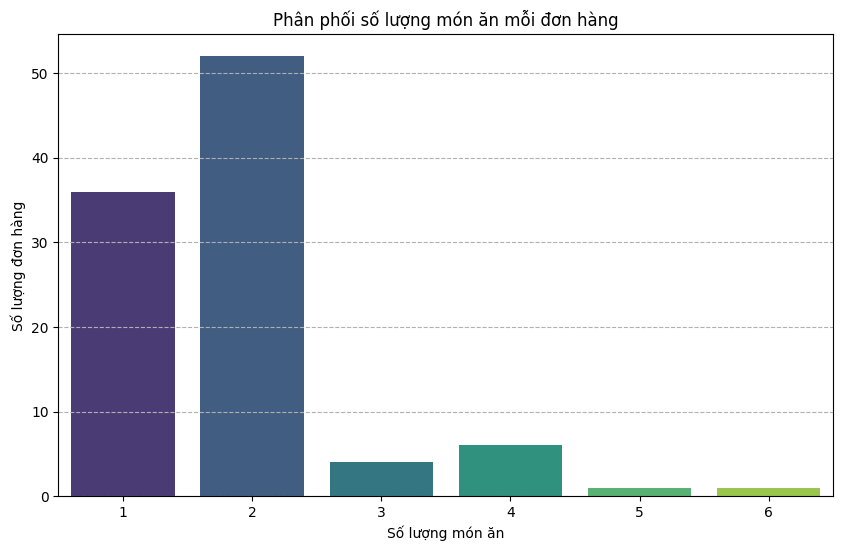


Phân phối trạng thái đơn hàng:
Order Status
Delivered    99
Returned      1
Name: count, dtype: int64


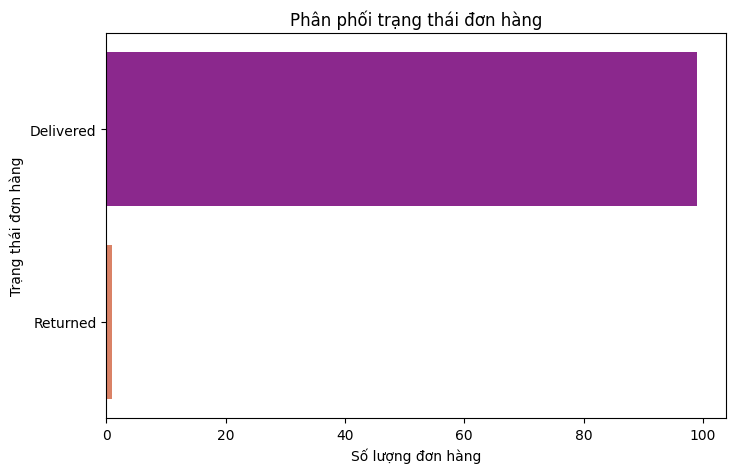


Phân phối điểm đánh giá (Đơn đã giao):
Rating
1.0     1
2.0     1
4.0     5
5.0    92
Name: count, dtype: int64


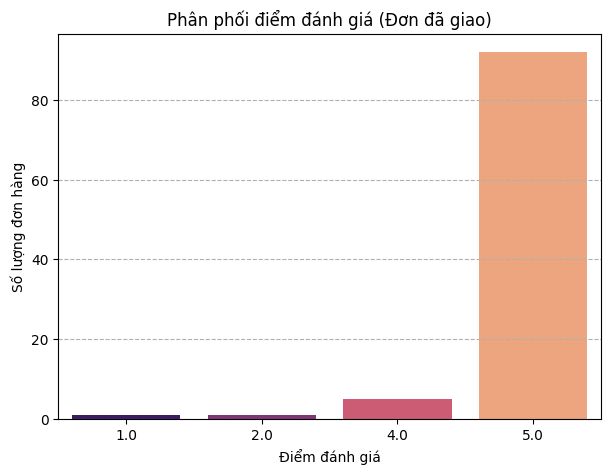

<ipython-input-46-76e5a3374e4b>:225: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=delivered_waittime_df, x='Rider wait time (minutes)', bins=20, kde=True, palette='viridis')


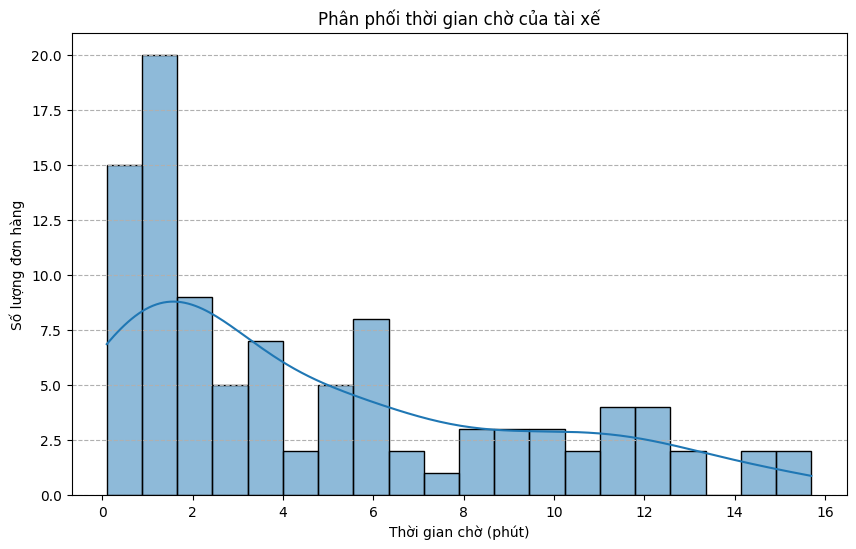


Số lượng đơn hàng theo giờ trong ngày:
Order_Hour
0      8
1      9
2      6
3      2
11     3
12     7
13     1
14     2
15     9
16     2
18     5
19     8
20    11
21    11
22     8
23     8
Name: count, dtype: int64


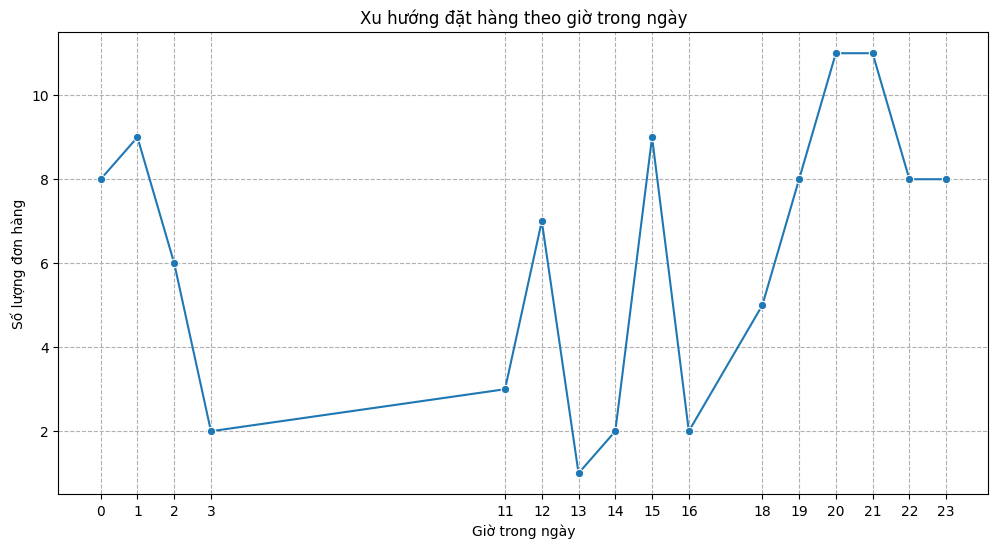


Phân phối trạng thái đánh dấu 'Order Ready Marked':
Order Ready Marked
Correctly      87
Incorrectly    11
Missed          2
Name: count, dtype: int64


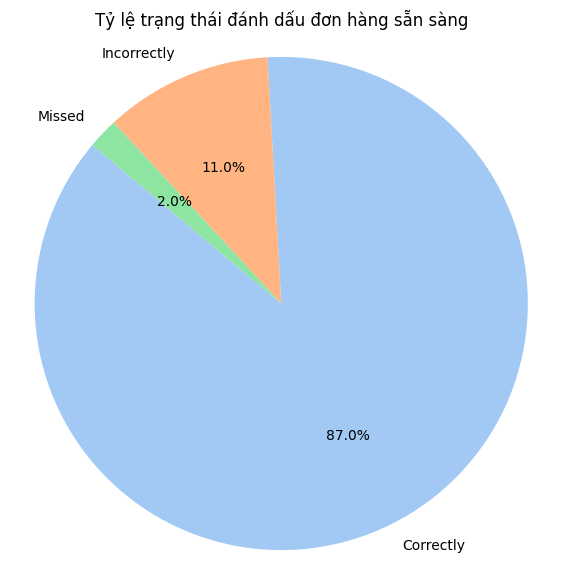

In [46]:
# Cài đặt thư viện nếu chưa có (thường đã có sẵn trong Colab)
# !pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Dữ liệu mẫu của bạn (vì dữ liệu đầy đủ rất lớn, tôi sẽ dùng một phần nhỏ làm ví dụ)
# Trong Colab thực tế, bạn sẽ tải file CSV lên
csv_data = """Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,Discount construct,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Cancellation / Rejection reason,Restaurant compensation (Cancellation),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
20320607,Swaad,Sector 4,Delhi NCR,6168884918,2024-09-10 23:38:00,Delivered,Zomato Delivery,3.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grilled Chicken Peri Peri Tangdi",40% off upto Rs.80,715.0,31.75,80.0,0.0,0.0,0.0,666.75,5.0,None,,18.35,11.6,Correctly,None,5d6c2b96db963098bc69768bea504c8bf46106a8a5178edf91a42e66a8179458
20320607,Swaad,Sector 4,Delhi NCR,6170707559,2024-09-10 23:34:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Fries, 1 x Fried Chicken Angara Tender, 1 x Grilled Chicken Angara Tender",Flat Rs.175 off,1179.0,50.2,175.0,0.0,0.0,0.0,1054.2,5.0,None,,16.95,3.6,Correctly,None,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5a626dbc4710568bff4
20320607,Swaad,Sector 4,Delhi NCR,6169375019,2024-09-10 15:52:00,Delivered,Zomato Delivery,0.5,1 x Bone in Peri Peri Grilled Chicken,40% off upto Rs.80,310.0,11.5,80.0,0.0,0.0,0.0,241.5,5.0,None,,14.05,12.2,Correctly,None,f93362f5ce5382657482d164e368186bcec9c6225fd93d374453a2e6983151de
20320607,Swaad,Sector 4,Delhi NCR,6151677434,2024-09-10 15:45:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Ghostbuster Tender, 1 x Angara Grilled Paneer (8 pcs)",40% off upto Rs.80,620.0,27.0,80.0,0.0,0.0,0.0,567.0,4.0,None,,19.0,3.3,Correctly,None,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d5c9d3ea550397d49ac
20320607,Swaad,Sector 4,Delhi NCR,6167540897,2024-09-10 15:04:00,Delivered,Zomato Delivery,2.0,"1 x Peri Peri Krispers, 1 x Fried Chicken Angara Tender",40% off upto Rs.80,584.0,25.2,80.0,0.0,0.0,0.0,529.2,5.0,None,,15.97,1.0,Correctly,None,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f110a3098eeb39596d9
20320607,Swaad,Sector 4,Delhi NCR,6164725184,2024-09-10 12:28:00,Delivered,Zomato Delivery,1.0,"1 x Grilled Chicken Jamaican Tangdi, 1 x Bone in Jamaican Grilled Chicken",40% off upto Rs.80,715.0,31.75,80.0,0.0,0.0,0.0,666.75,5.0,None,,20.48,1.0,Correctly,None,4103fd4f3ee2166d322e76fabd420ae15f14a2816ca5a3be43133260bb1327f4
20320607,Swaad,Sector 4,Delhi NCR,6151460444,2024-09-10 00:03:00,Delivered,Zomato Delivery,6.0,1 x Bone in Jamaican Grilled Chicken,40% off upto Rs.80,370.0,14.5,80.0,0.0,0.0,0.0,304.5,5.0,None,,10.53,7.0,Incorrectly,None,24d7ca74eb1efe217e88062d2519403ba11d62f5953186d71cfd3a02233275ab
20320607,Swaad,Sector 4,Delhi NCR,6167255032,2024-09-09 22:54:00,Delivered,Zomato Delivery,2.0,1 x Bone in Angara Grilled Chicken,40% off upto Rs.80,310.0,11.5,80.0,0.0,0.0,0.0,241.5,5.0,None,,9.68,1.5,Correctly,None,fa1710c1c41dd4f29b810b78f8e7c08a356ca0fdc3930713e020e1ed258ceb4e
20320607,Swaad,Sector 4,Delhi NCR,6167184688,2024-09-09 22:51:00,Delivered,Zomato Delivery,1.0,"1 x Fried Chicken Angara Tender, 1 x Angara Rice",40% off upto Rs.80,473.0,19.65,80.0,0.0,0.0,0.0,412.65,5.0,None,,15.2,8.3,Correctly,None,c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35dd5930ede1d8a643da
20320607,Swaad,Sector 4,Delhi NCR,6163081676,2024-09-09 15:22:00,Delivered,Zomato Delivery,0.5,1 x Grilled Chicken Peri Peri Tangdi,40% off upto Rs.80,405.0,16.25,80.0,0.0,0.0,0.0,341.25,5.0,None,,11.38,3.7,Correctly,None,ac2ee09679412d4248884cdfd7637d9b3529eeac0e2f27a6c143a53bba064764
20320607,Swaad,Sector 4,Delhi NCR,6164758457,2024-09-08 22:03:00,Delivered,Zomato Delivery,6.0,1 x Bone in Jamaican Grilled Chicken,50% off upto Rs.100,370.0,13.5,100.0,0.0,0.0,0.0,283.5,5.0,None,,11.67,5.5,Correctly,None,24d7ca74eb1efe217e88062d2519403ba11d62f5953186d71cfd3a02233275ab
20320607,Swaad,Sector 4,Delhi NCR,6159645418,2024-09-08 21:49:00,Delivered,Zomato Delivery,2.0,1 x Bone in Jamaican Grilled Chicken,40% off upto Rs.80,645.0,28.25,80.0,0.0,0.0,0.0,593.25,5.0,None,,14.27,5.9,Correctly,None,e1248ba01f5b3ffbab3adde359bfc48adb924a123dd15daed0063f1c695e5c01
20320607,Swaad,Sector 4,Delhi NCR,6163201423,2024-09-08 19:48:00,Delivered,Zomato Delivery,3.0,1 x Bone in Smoky Bbq Grilled Chicken,50% off upto Rs.100,310.0,10.5,100.0,0.0,0.0,0.0,220.5,2.0,None,,17.23,8.8,Correctly,None,db8331544bffcb3d70e0a6eacf709657d5bc03f4eec32d293feb61c9fcad86b9
20320607,Swaad,Sector 4,Delhi NCR,6161956272,2024-09-08 19:48:00,Delivered,Zomato Delivery,4.0,1 x Fried Chicken Peri Peri Tender,40% off upto Rs.80,460.0,19.0,80.0,0.0,0.0,0.0,399.0,5.0,None,,16.83,12.1,Correctly,None,8cc49e1c87db248d9bf994de02c7da0229cd3b46bb99002b299345a60d562a7a
20320607,Swaad,Sector 4,Delhi NCR,6153489136,2024-09-08 19:21:00,Delivered,Zomato Delivery,4.0,"2 x Tipsy Tiger Ginger Ale, 1 x Bone in Jamaican Grilled Chicken, 1 x Bone in Smoky Bbq Grilled Chicken",No Discount,858.1,42.91,0.0,0.0,0.0,0.0,901.01,5.0,None,,20.3,8.6,Correctly,None,a4fb8d5447830dfa482d20ce3a20bce637c3a956fba93cee95726869ddb39231
20320607,Swaad,Sector 4,Delhi NCR,6163049565,2024-09-08 18:33:00,Delivered,Zomato Delivery,3.0,1 x Bone in Angara Grilled Chicken,40% off upto Rs.80,695.0,30.75,80.0,0.0,0.0,0.0,645.75,5.0,None,,18.05,11.1,Correctly,None,7ecba12675df48b9b8c245c81a354abc2c6a4a8dd4d28be92f2b955fae0c8150
20320607,Swaad,Sector 4,Delhi NCR,6155177885,2024-09-08 15:23:00,Delivered,Zomato Delivery,5.0,1 x Fried Chicken Peri Peri Tender,40% off upto Rs.80,460.0,19.0,80.0,0.0,0.0,0.0,399.0,5.0,None,,14.97,5.6,Correctly,None,e0501d56d905f021333ed64371ab8635f8be47ea5f8be47ea516aaf8f2424da63793a6bc6
20320607,Swaad,Sector 4,Delhi NCR,6156719166,2024-09-08 02:55:00,Delivered,Zomato Delivery,3.0,1 x Angara Aloo Tuk Tuki,40% off upto Rs.80,218.0,6.9,80.0,0.0,0.0,0.0,144.9,5.0,None,,20.75,10.9,Correctly,None,f9e9f7e806c4b5601873c0b9ff2eac2a45b4ab29d61572bd0c8eb8d3ec0487ce
20320607,Swaad,Sector 4,Delhi NCR,6158533370,2024-09-08 02:23:00,Delivered,Zomato Delivery,4.0,1 x Grilled Chicken Peri Peri Tangdi,50% off upto Rs.100,405.0,15.25,100.0,0.0,0.0,0.0,320.25,5.0,None,,10.8,3.2,Incorrectly,None,75386768d73d08a035ee5cbb91c59ed2f971d6f770eaf083420f7b3b8ed49ee9
20320607,Swaad,Sector 4,Delhi NCR,6152228975,2024-09-08 01:57:00,Delivered,Zomato Delivery,6.0,1 x Grilled Chicken Smoky BBQ Tender,50% off upto Rs.100,435.0,16.75,100.0,0.0,0.0,0.0,351.75,5.0,None,,9.42,1.4,Correctly,None,65235b6b25a0daf7bb923d0ca8c76a58581c05ca5483bdeee3f88df77d6ffd36
20320607,Swaad,Sector 4,Delhi NCR,6157229636,2024-09-07 21:24:00,Delivered,Zomato Delivery,2.0,1 x Grilled Chicken Smoky BBQ Tangdi,50% off upto Rs.100,635.0,26.75,100.0,0.0,0.0,0.0,561.75,5.0,None,,12.38,1.6,Correctly,None,bf3dbdf507a5e0b61ee60d981dc53f57fca7cb06d05f78794472587fc7f9093f
20320607,Swaad,Sector 4,Delhi NCR,6160420881,2024-09-07 20:35:00,Delivered,Zomato Delivery,2.0,1 x Bone in Jamaican Grilled Chicken,40% off upto Rs.80,310.0,11.5,80.0,0.0,0.0,0.0,241.5,5.0,None,,16.33,3.2,Missed,None,31e6e136219f784a75bb09e36e5ed588c332aa7ce3aef6d74c16f3e7560768de
20320607,Swaad,Sector 4,Delhi NCR,6158429833,2024-09-07 18:09:00,Delivered,Zomato Delivery,5.0,"1 x Animal Fries, 1 x Salted Fries",40% off upto Rs.80,524.0,22.2,80.0,0.0,0.0,0.0,466.2,4.0,None,,16.88,13.3,Correctly,None,49e49a6a003c4e24baf07ad57097ef267b67bd47b86120650a6376eb18299bbb
20320607,Swaad,Sector 4,Delhi NCR,6156152215,2024-09-07 16:00:00,Delivered,Zomato Delivery,2.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Fried Chicken Angara Tender",Flat Rs.175 off,910.0,36.75,175.0,0.0,0.0,0.0,771.75,5.0,None,,19.82,0.7,Correctly,None,80650c4426a3fc8d969e8b43126bc197f68b301ca14e037644fc2c5218707d6b
20320607,Swaad,Sector 4,Delhi NCR,6159249185,2024-09-07 12:43:00,Delivered,Zomato Delivery,4.0,1 x Bone in Kabuli Grilled Chicken,40% off upto Rs.80,310.0,11.5,80.0,0.0,0.0,0.0,241.5,5.0,None,,19.2,15.4,Correctly,None,b85edd5052b39954b086319952ca2d76184ce8d424fe20fa549b9ade2b4e173f
20320607,Swaad,Sector 4,Delhi NCR,6159181202,2024-09-07 02:00:00,Delivered,Zomato Delivery,4.0,1 x Bone in Peri Peri Grilled Chicken,50% off upto Rs.100,585.0,24.25,100.0,0.0,0.0,0.0,509.25,5.0,None,,10.63,1.7,Correctly,None,6f68ba8ce8a4c4b6b82a095980151c96ba4d59a02ac267ba67f7d19cec84d3c2
20320607,Swaad,Sector 4,Delhi NCR,6158034744,2024-09-07 00:58:00,Delivered,Zomato Delivery,1.0,1 x Fried Chicken Peri Peri Tender,Flat Rs.80 off,325.0,12.25,80.0,0.0,0.0,0.0,257.25,5.0,None,,7.77,5.4,Incorrectly,None,432e8f108fb6faf72c98a5d5299f6a52d58e948f9d6b0c8aef39b3b4976d2dc4
20320607,Swaad,Sector 4,Delhi NCR,6144978141,2024-09-06 23:25:00,Delivered,Zomato Delivery,4.0,1 x Fried Chicken Peri Peri Tender,Flat Rs.80 off,325.0,12.25,80.0,0.0,0.0,0.0,257.25,5.0,None,,13.05,1.8,Correctly,None,693e71ee644f2badf452477f2be8483e5211592ae22cd49bf81a164b125af2b0
20320607,Swaad,Sector 4,Delhi NCR,6155011355,2024-09-06 21:50:00,Delivered,Zomato Delivery,8.0,"1 x Bone in Angara Grilled Chicken, 1 x Bone in Jamaican Grilled Chicken",50% off upto Rs.100,895.0,39.75,100.0,0.0,0.0,0.0,834.75,5.0,None,,13.0,0.4,Correctly,None,f948793b932876cb63b8bc6b3cbe85d5d442c5e2fc1c9da348c903fead35b81a
20320607,Swaad,Sector 4,Delhi NCR,6157562143,2024-09-06 21:23:00,Delivered,Zomato Delivery,3.0,"1 x Jamaican Sauce, 2 x Grilled Chicken Jamaican Tender",Flat Rs.80 off,680.0,30.0,80.0,0.0,0.0,0.0,630.0,5.0,None,,15.98,2.4,Correctly,None,a84ab19e1691226e429b3f4495db99b2937f431d216e1899dcde06722eb4daee
20320607,Swaad,Sector 4,Delhi NCR,6155576594,2024-09-06 20:59:00,Delivered,Zomato Delivery,3.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x AAC Signature Fries, 1 x Bone in Peri Peri Grilled Chicken",Flat Rs.80 off,1084.0,50.2,80.0,0.0,0.0,0.0,1054.2,5.0,None,,10.67,0.9,Correctly,None,e27eadf180f5389911e6c5b369ac1ae5ac05259d54bc65721819869ee14e18c7
20320607,Swaad,Sector 4,Delhi NCR,6149438913,2024-09-06 20:36:00,Delivered,Zomato Delivery,1.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Grilled Chicken Peri Peri Tender, 1 x Grilled Chicken Angara Tenders + Salted Fries",Flat Rs.175 off,1290.0,55.75,175.0,0.0,0.0,0.0,1170.75,5.0,None,,22.43,1.2,Correctly,None,096a9f7a0c5cf71b57729f2de20cf0080b608dffe8e9c77bf9fa4a3055568590
20320607,Swaad,Sector 4,Delhi NCR,6157743878,2024-09-06 20:36:00,Delivered,Zomato Delivery,3.0,1 x Bone in Jamaican Grilled Chicken,40% off upto Rs.80,695.0,30.75,80.0,0.0,0.0,0.0,645.75,5.0,None,,7.87,4.7,Incorrectly,None,ced9e9119fce4573dfcda41998964378f3a2a079d70e503a603cb001658b75ce
20320607,Swaad,Sector 4,Delhi NCR,6158241703,2024-09-06 20:08:00,Delivered,Zomato Delivery,2.0,1 x Bone in Jamaican Grilled Chicken,50% off upto Rs.100,310.0,10.5,100.0,0.0,0.0,0.0,220.5,5.0,None,,8.83,14.3,Incorrectly,None,61e7481fdb65a6580cd5520d12517ba4dd78ef3c7d4df2b6ff475d48075ea42c
20320607,Swaad,Sector 4,Delhi NCR,6156620875,2024-09-06 15:09:00,Delivered,Zomato Delivery,4.0,1 x Fried Chicken Peri Peri Tender,40% off upto Rs.80,325.0,12.25,80.0,0.0,0.0,0.0,257.25,5.0,None,,3.35,5.4,Incorrectly,None,693e71ee644f2badf452477f2be8483e5211592ae22cd49bf81a164b125af2b0
20320607,Swaad,Sector 4,Delhi NCR,6154403375,2024-09-06 14:49:00,Delivered,Zomato Delivery,6.0,1 x Bone in Kabuli Grilled Chicken,40% off upto Rs.80,310.0,11.5,80.0,0.0,0.0,0.0,241.5,5.0,None,,16.42,8.5,Incorrectly,None,5393bd13d96ca939871e15d6f950f8d5ce66ed2d9688b96e0c4f7d1ec2a5b41f
20320607,Swaad,Sector 4,Delhi NCR,6154147762,2024-09-06 11:39:00,Delivered,Zomato Delivery,1.0,1 x Animal Fries,50% off upto Rs.100,355.0,12.75,100.0,0.0,0.0,0.0,267.75,5.0,None,,17.73,11.5,Correctly,None,81836124bc23518067df460ac476f26b1f0e3cda956fc9aee91f52c6f92a9114
20320607,Swaad,Sector 4,Delhi NCR,6150715172,2024-09-06 03:24:00,Delivered,Zomato Delivery,3.0,1 x AAC Signature Krispers,50% off upto Rs.100,199.0,4.98,99.5,0.0,0.0,0.0,104.48,5.0,None,,10.95,0.8,Correctly,None,f9e9f7e806c4b5601873c0b9ff2eac2a45b4ab29d61572bd0c8eb8d3ec0487ce
20320607,Swaad,Sector 4,Delhi NCR,6150789630,2024-09-06 02:03:00,Delivered,Zomato Delivery,1.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x Fried Chicken Peri Peri Tenders + Peri Peri Fries",Flat Rs.175 off,775.0,30.0,175.0,0.0,0.0,0.0,630.0,5.0,None,,16.92,2.5,Correctly,None,096a9f7a0c5cf71b57729f2de20cf0080b608dffe8e9c77bf9fa4a3055568590
20320607,Swaad,Sector 4,Delhi NCR,6151158050,2024-09-06 01:54:00,Delivered,Zomato Delivery,7.0,"1 x Angara Aloo Tuk Tuki, 1 x AAC Signature Fries",50% off upto Rs.100,347.0,12.35,100.0,0.0,0.0,0.0,259.35,5.0,None,,25.52,11.8,Correctly,None,6292149fd8cc18ad66b1804144ff15fa31e5f1ee90f87f0dee8dbaf97b345b94
20320607,Swaad,Sector 4,Delhi NCR,6155965734,2024-09-06 01:10:00,Delivered,Zomato Delivery,4.0,1 x Animal Fries,50% off upto Rs.100,355.0,12.75,100.0,0.0,0.0,0.0,267.75,5.0,None,,13.3,1.0,Correctly,None,ebd60c19b0f492b7377b19d314ab1ecd690e365ce5744030851d2932feb4ade7
20320607,Swaad,Sector 4,Delhi NCR,6155526018,2024-09-06 00:48:00,Delivered,Zomato Delivery,7.0,1 x Grilled Chicken Jamaican Tender,50% off upto Rs.100,310.0,10.5,100.0,0.0,0.0,0.0,220.5,5.0,None,,7.87,1.2,Correctly,None,9ae38c952fdef0c4c067098312f0be853006239e7f7a7304008d0b7ae47b0917
20320607,Swaad,Sector 4,Delhi NCR,6146261091,2024-09-05 23:50:00,Delivered,Zomato Delivery,4.0,"1 x Animal Fries, 1 x Grilled Chicken Smoky BBQ Tender",40% off upto Rs.80,665.0,29.25,80.0,0.0,0.0,0.0,614.25,5.0,None,,15.67,3.9,Correctly,None,19cb886d7bd07a82573682a85d6042bc2fa0eeda217659f116b1930308a0ce38
20320607,Swaad,Sector 4,Delhi NCR,6155286499,2024-09-05 23:42:00,Delivered,Zomato Delivery,8.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x Bone in Jamaican Grilled Chicken",50% off upto Rs.100,620.0,26.0,100.0,0.0,0.0,0.0,546.0,5.0,None,,18.48,4.5,Correctly,None,dbb7b0b85ee66218f881e953ecd62bbdc356188fed58a43e27ba37d0c06dc552
20320607,Swaad,Sector 4,Delhi NCR,6155319009,2024-09-05 22:57:00,Delivered,Zomato Delivery,3.0,1 x Bone in Jamaican Grilled Chicken,Flat Rs.175 off,755.0,29.0,175.0,0.0,0.0,0.0,609.0,5.0,None,,11.93,0.9,Correctly,None,0a299b2d813b99f45018a6af6c423279b5a0cba30d8c7f3a3f0a69fdfae3c865
20320607,Swaad,Sector 4,Delhi NCR,6155343744,2024-09-05 20:56:00,Delivered,Zomato Delivery,1.0,1 x Grilled Chicken Smoky BBQ Tender,Flat Rs.80 off,435.0,17.75,80.0,0.0,0.0,0.0,372.75,5.0,None,,9.93,0.3,Correctly,None,c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35dd5930ede1d8a643da
20320607,Swaad,Sector 4,Delhi NCR,6151641967,2024-09-05 19:48:00,Delivered,Zomato Delivery,2.0,1 x Fried Chicken Angara Tender,50% off upto Rs.100,325.0,11.25,100.0,0.0,0.0,0.0,236.25,5.0,None,,13.63,1.4,Correctly,None,bcfa051a96036fe2f67b8b7d0f27b37d983dede68aab0aeb2541811d09b0c859
20320607,Swaad,Sector 4,Delhi NCR,6152673880,2024-09-05 19:20:00,Delivered,Zomato Delivery,6.0,1 x Fried Chicken Peri Peri Tender,No Discount,629.0,31.45,0.0,0.0,0.0,0.0,660.45,4.0,None,,19.0,0.5,Correctly,None,6bd9d2a22ced3c8d3466c08c0570a30c671b1f8a837c51f788966332398a6a45
20320607,Swaad,Sector 4,Delhi NCR,6145690912,2024-09-05 02:14:00,Delivered,Zomato Delivery,7.0,1 x Bone in Jamaican Grilled Chicken,50% off upto Rs.100,585.0,24.25,100.0,0.0,0.0,0.0,509.25,5.0,None,,14.42,1.0,Correctly,None,f3fc5884a2568a19739f9ac18b494e1c504694463152534c3cf99614585fafdd
20320607,Swaad,Sector 4,Delhi NCR,6152587141,2024-09-05 02:04:00,Delivered,Zomato Delivery,10.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x Bone in Jamaican Grilled Chicken",No Discount,1230.0,32.25,0.0,585.0,0.0,0.0,677.25,5.0,None,,18.23,7.1,Correctly,None,fcf74c5042b5d8f18e224c0e35d026cdff1a07e7508262d1f70f5b57aa9451a1
20320607,Swaad,Sector 4,Delhi NCR,6143319424,2024-09-05 01:30:00,Delivered,Zomato Delivery,10.0,"1 x Fried Chicken Peri Peri Tender, 1 x Grilled Chicken Jamaican Tender",No Discount,815.0,22.25,0.0,370.0,0.0,0.0,467.25,5.0,None,,15.8,1.2,Correctly,None,51f61d6e41c956156e1b8be1c84f2e6af08f784750003ae78ec808d0b333d403
20320607,Swaad,Sector 4,Delhi NCR,6152649630,2024-09-05 01:23:00,Delivered,Zomato Delivery,4.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Bone in Peri Peri Grilled Chicken",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,15.4,2.2,Correctly,None,1e7b5292b0110052dbef10afb693806d92a549b702bb3e72dc27305c4fa02aa1
20320607,Swaad,Sector 4,Delhi NCR,6146501186,2024-09-05 01:16:00,Delivered,Zomato Delivery,8.0,2 x Bone in Jamaican Grilled Chicken,No Discount,840.0,21.0,0.0,420.0,0.0,0.0,441.0,5.0,None,,17.03,1.2,Correctly,None,233304762f6d9e8903e3fd792fa1ab106425d77d02a7ae09898b5c78de784284
20320607,Swaad,Sector 4,Delhi NCR,6145930056,2024-09-05 00:38:00,Delivered,Zomato Delivery,9.0,2 x Bone in Kabuli Grilled Chicken,No Discount,1170.0,29.25,0.0,585.0,0.0,0.0,614.25,5.0,None,,18.73,2.8,Correctly,None,cffe01c0be11370e104086d48ca7464817fb4b0e69e4a54a6846d9446fda1398
20320607,Swaad,Sector 4,Delhi NCR,6145885503,2024-09-05 00:25:00,Delivered,Zomato Delivery,10.0,"1 x Fried Chicken Angara Tender, 1 x Salted Fries",No Discount,494.0,16.25,0.0,169.0,0.0,0.0,341.25,5.0,None,,24.62,0.5,Correctly,None,0eb263c3300bd21008a9dc15f0b90a6033a0670799a9d7231b1dc447ba376118
20320607,Swaad,Sector 4,Delhi NCR,6153460436,2024-09-05 00:21:00,Delivered,Zomato Delivery,10.0,"1 x Fried Chicken Peri Peri Tender, 1 x Garlic Aioli, 1 x Fried Chicken Classic Tender, 1 x Indian Pico De-Gallo",No Discount,905.0,26.0,0.0,385.0,0.0,0.0,546.0,5.0,None,,20.03,2.1,Correctly,None,932461e0c80b5cd50d0585d7081ae87732ddf0e5e4d9ea6fc978e38528705fb8
20320607,Swaad,Sector 4,Delhi NCR,6149384788,2024-09-05 00:14:00,Delivered,Zomato Delivery,1.0,"1 x Grilled Chicken Jamaican Tender, 1 x Grilled Chicken Peri Peri Tender",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,14.43,2.3,Correctly,None,d79a64d183f2c30be582132ff90226e91149f4bef5f2094437bd3e1a297a3386
20320607,Swaad,Sector 4,Delhi NCR,6153295379,2024-09-05 00:13:00,Delivered,Zomato Delivery,2.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x Fried Chicken Classic Tender",No Discount,635.0,16.25,0.0,310.0,0.0,0.0,341.25,5.0,None,,17.17,2.5,Correctly,Poor taste or quality,5e8a4ed663825c80c69777fdfb19b3b07ba28e3e060cc9c9ba3ee5913191d6cf
20320607,Swaad,Sector 4,Delhi NCR,6151765091,2024-09-04 23:42:00,Delivered,Zomato Delivery,3.0,"1 x Bone in Angara Grilled Chicken, 1 x Bone in Jamaican Grilled Chicken",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,16.0,0.8,Correctly,None,63d92052e68f12bb766da2073286771ff9fdb5195d1778f74c93676f1bbcb2f4
20320607,Swaad,Sector 4,Delhi NCR,6151170863,2024-09-04 23:31:00,Delivered,Zomato Delivery,1.0,"1 x Fried Chicken Peri Peri Tender, 1 x AAC Saucy Fries",No Discount,600.0,16.25,0.0,275.0,0.0,0.0,341.25,5.0,None,,20.73,14.7,Correctly,None,1837740b4c913731f06809b4939f99049af0a01db4165c14e2ff12a324e861c7
20320607,Swaad,Sector 4,Delhi NCR,6148418552,2024-09-04 23:27:00,Delivered,Zomato Delivery,1.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Grilled Chicken Peri Peri Tender",No Discount,745.0,21.75,0.0,310.0,0.0,0.0,456.75,5.0,None,,16.33,5.6,Missed,None,096a9f7a0c5cf71b57729f2de20cf0080b608dffe8e9c77bf9fa4a3055568590
20320607,Swaad,Sector 4,Delhi NCR,6151566063,2024-09-04 22:51:00,Delivered,Zomato Delivery,2.0,"1 x Bone in Angara Grilled Chicken, 1 x Bone in Peri Peri Grilled Chicken",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,16.65,11.1,Correctly,None,67fcb929df09c634f7ea7180357cba65cf6fcabf87df2356ebffec469ddcb0ab
20320607,Swaad,Sector 4,Delhi NCR,6145781285,2024-09-04 22:34:00,Delivered,Zomato Delivery,2.0,2 x Bone in Peri Peri Grilled Chicken,No Discount,1290.0,32.25,0.0,645.0,0.0,0.0,677.25,5.0,None,,15.92,5.9,Correctly,None,e1248ba01f5b3ffbab3adde359bfc48adb924a123dd15daed0063f1c695e5c01
20320607,Swaad,Sector 4,Delhi NCR,6151947675,2024-09-04 22:16:00,Delivered,Zomato Delivery,1.0,2 x Bone in Peri Peri Grilled Chicken,No Discount,1170.0,29.25,0.0,585.0,0.0,0.0,614.25,5.0,None,,14.88,3.4,Correctly,None,f27f1678df564169a9126446616480abcec3d2e0f70808500182ab2254ce1ca0
20320607,Swaad,Sector 4,Delhi NCR,6149007950,2024-09-04 22:12:00,Delivered,Zomato Delivery,3.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Bone in Smoky Bbq Grilled Chicken",No Discount,1170.0,29.25,0.0,585.0,0.0,0.0,614.25,5.0,None,,15.88,3.9,Correctly,None,056027e8e28c1ebd006f8c0060d278b7033877c64b2a676909e7079d0857db06
20320607,Swaad,Sector 4,Delhi NCR,6147952636,2024-09-04 21:49:00,Delivered,Zomato Delivery,1.0,"1 x Grilled Chicken Smoky BBQ Tender, 1 x Grilled Chicken Jamaican Tender",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,13.53,0.8,Correctly,None,c1d52f9d0acfcc61c0a477f04eae4f4e1fbe35f3ceae6274cdf80b22e535200a
20320607,Swaad,Sector 4,Delhi NCR,6146517611,2024-09-04 21:44:00,Delivered,Zomato Delivery,6.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x Grilled Chicken Peri Peri Tender",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,8.97,1.4,Correctly,None,fa41cad255318d632dc4b34e6af0ab45fe7e21c680c03b078e272e09bae8c38d
20320607,Swaad,Sector 4,Delhi NCR,6147223342,2024-09-04 21:44:00,Delivered,Zomato Delivery,4.0,"1 x Fried Chicken Classic Tender, 1 x Grilled Chicken Peri Peri Tender",No Discount,635.0,16.25,0.0,310.0,0.0,0.0,341.25,4.0,None,,11.05,0.7,Correctly,None,9a6a44e1b5d0d38f838c0ca28f23bc57d95787ecd41f8b4438124ea7d76f3beb
20320607,Swaad,Sector 4,Delhi NCR,6148317461,2024-09-04 21:39:00,Delivered,Zomato Delivery,2.0,"1 x Fried Chicken Peri Peri Tender, 1 x Grilled Chicken Smoky BBQ Tender",No Discount,895.0,23.0,0.0,435.0,0.0,0.0,483.0,5.0,None,,12.68,1.0,Correctly,None,f948ecb190a2faa06694f5ef9e00c7bc3e05adcaf18129650305b0118b4ea48d
20320607,Swaad,Sector 4,Delhi NCR,6150575094,2024-09-04 21:16:00,Delivered,Zomato Delivery,1.0,"1 x Bone in Kabuli Grilled Chicken, 1 x Fried Chicken Classic Tender",No Discount,635.0,16.25,0.0,310.0,0.0,0.0,341.25,5.0,None,,25.88,10.5,Correctly,None,0b5fd6204af7c52628a559147ac7fc08b4b4db49d12af218c47690f8e813a371
20320607,Swaad,Sector 4,Delhi NCR,6147352865,2024-09-04 21:13:00,Delivered,Zomato Delivery,4.0,"2 x Grilled Chicken Smoky BBQ Tangdi, 1 x Fried Chicken Classic Tender, 1 x Grilled Chicken Jamaican Tender",No Discount,1445.0,36.5,0.0,715.0,0.0,0.0,766.5,5.0,None,,22.9,1.5,Correctly,None,7babac4e1c879400e88c6246478861778312573e3b831070ce9dce1542091e05
20320607,Swaad,Sector 4,Delhi NCR,6152604746,2024-09-04 20:59:00,Delivered,Zomato Delivery,3.0,"1 x Bone in Kabuli Grilled Chicken, 1 x Bone in Jamaican Grilled Chicken",No Discount,730.0,21.0,0.0,310.0,0.0,0.0,441.0,5.0,None,,15.77,2.0,Correctly,None,645ceb83ae6e9f8ebe14a657c086090aab3ec9ec1ab3b627e7138daebe3b0ef0
20320607,Swaad,Sector 4,Delhi NCR,6125480550,2024-09-04 20:52:00,Delivered,Zomato Delivery,3.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Bone in Smoky Bbq Grilled Chicken",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,12.02,1.1,Correctly,None,25ac12ce2f426c43ddde044e3fba270bc4854fa2ecdc36c8526d18085af29511
20320607,Swaad,Sector 4,Delhi NCR,6147529218,2024-09-04 20:48:00,Delivered,Zomato Delivery,1.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x Bone in Jamaican Grilled Chicken",No Discount,1170.0,29.25,0.0,585.0,0.0,0.0,614.25,5.0,None,,13.22,0.9,Correctly,None,9898e405eb3e4729af2131be8ec1b2bba0f861a9f1c6e179fb7f54023addadc8
20320607,Swaad,Sector 4,Delhi NCR,6151551465,2024-09-04 20:17:00,Returned,Zomato Delivery,7.0,"1 x Grilled Chicken Angara Tender, 1 x Grilled Chicken Peri Peri Tender",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,Cancelled by Zomato,233.58,11.07,3.1,Incorrectly,None,3a6f85e21f147c838f0143b942ba0c0e42178fc8aa27c7cca83398ce45e8b80d
20320607,Swaad,Sector 4,Delhi NCR,6145952899,2024-09-04 20:15:00,Delivered,Zomato Delivery,1.0,"1 x Grilled Chicken Peri Peri Tangdi, 1 x Grilled Chicken Ghostbuster Tangdi",No Discount,810.0,20.25,0.0,405.0,0.0,0.0,425.25,4.0,None,,13.9,0.3,Correctly,None,6c7f524181b7529ad6138cb29e52a10b14fc7c3bd077d0a3e09068c9cdbfaf51
20320607,Swaad,Sector 4,Delhi NCR,6152451484,2024-09-04 19:49:00,Delivered,Zomato Delivery,3.0,"2 x Bone in Peri Peri Grilled Chicken, 2 x Garlic Aioli",No Discount,960.0,24.0,0.0,480.0,0.0,0.0,504.0,5.0,None,,19.27,0.1,Correctly,None,3a2f94ba1632c59e184821af36cf18763ebacbd2119bfe63d729077d3c4fe499
20320607,Swaad,Sector 4,Delhi NCR,6145028896,2024-09-04 19:40:00,Delivered,Zomato Delivery,7.0,2 x Bone in Jamaican Grilled Chicken,No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,11.48,0.6,Correctly,None,50e4a3c3e292b0826f0225967b64baeb7c0b2d19f48271092bfa727b6612b492
20320607,Swaad,Sector 4,Delhi NCR,6143017232,2024-09-04 19:12:00,Delivered,Zomato Delivery,2.0,"2 x India Dynamite sauce, 2 x Bone in Angara Grilled Chicken, 1 x AAC Special Slaw",No Discount,1498.0,42.65,0.0,645.0,0.0,0.0,895.65,5.0,None,,10.1,1.2,Correctly,None,8a766ef646ef1de0bbbde631f5117d0bee4dceb361852fb00024f75b1e51011b
20320607,Swaad,Sector 4,Delhi NCR,6146212039,2024-09-04 18:36:00,Delivered,Zomato Delivery,7.0,2 x Bone in Jamaican Grilled Chicken,No Discount,2310.0,57.75,0.0,1155.0,0.0,0.0,1212.75,5.0,None,,18.8,5.4,Correctly,None,86e308b8028b462169dd40781a734737233dce0204ab2f13d97b9f40e955f88c
20320607,Swaad,Sector 4,Delhi NCR,6146853616,2024-09-04 18:28:00,Delivered,Zomato Delivery,8.0,"1 x Bone in Smoky Bbq Grilled Chicken, 1 x Animal Fries",No Discount,665.0,17.75,0.0,310.0,0.0,0.0,372.75,5.0,None,,14.15,5.7,Correctly,None,072368d2f5e6867fcc4627b23bed6082e37f640c05bdf037d73a17afd63d8c60
20320607,Swaad,Sector 4,Delhi NCR,6130555847,2024-09-04 18:13:00,Delivered,Zomato Delivery,1.0,"2 x Grilled Chicken Peri Peri Tender, 2 x Salted Krispers",No Discount,978.0,24.45,0.0,489.0,0.0,0.0,513.45,1.0,None,,14.28,5.9,Correctly,None,f6964b4dbe5c91e63c19798e3aeaeae5bd1b4661f6531954931b2caec13b5adf
20320607,Swaad,Sector 4,Delhi NCR,6151773822,2024-09-04 16:42:00,Delivered,Zomato Delivery,2.0,"1 x Cafreal dip, 1 x Indian Pico De-Gallo, 1 x Bone in Peri Peri Grilled Chicken, 1 x Bone in Angara Grilled Chicken",No Discount,740.0,18.5,0.0,370.0,0.0,0.0,388.5,5.0,None,,19.73,9.9,Correctly,None,8a766ef646ef1de0bbbde631f5117d0bee4dceb361852fb00024f75b1e51011b
20320607,Swaad,Sector 4,Delhi NCR,6143779367,2024-09-04 15:52:00,Delivered,Zomato Delivery,2.0,2 x Bone in Jamaican Grilled Chicken,No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,14.3,3.4,Correctly,None,338de5c25cf918a023998c410b84ad8d891ff2ee8dff49541ce3b141d02ea2dc
20320607,Swaad,Sector 4,Delhi NCR,6146106285,2024-09-04 15:26:00,Delivered,Zomato Delivery,4.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Bone in Smoky Bbq Grilled Chicken",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,18.32,5.4,Correctly,None,1383b3f90bf1fd9be331f38e7727dd54f588ec667bf2efdd9c36a7c0e7a526a3
20320607,Swaad,Sector 4,Delhi NCR,6146094951,2024-09-04 15:21:00,Delivered,Zomato Delivery,7.0,"1 x Animal Fries, 1 x Bone in Smoky Bbq Grilled Chicken",No Discount,665.0,17.75,0.0,310.0,0.0,0.0,372.75,5.0,None,,19.65,6.2,Correctly,None,10f3615f9751e530b4702559f84c8cbf289de17968c8ef594c5b92fe633454c8
20320607,Swaad,Sector 4,Delhi NCR,6148163639,2024-09-04 14:56:00,Delivered,Zomato Delivery,7.0,"1 x Animal Fries, 1 x Grilled Chicken Jamaican Tender",No Discount,790.0,21.75,0.0,355.0,0.0,0.0,456.75,5.0,None,,21.37,0.6,Correctly,None,ede1896d41535f1d4dfce1408dabb92aa7dac54818639dd952fce03ad9d19651
20320607,Swaad,Sector 4,Delhi NCR,6147899210,2024-09-04 13:56:00,Delivered,Zomato Delivery,0.5,"1 x Fried Chicken Angara Tender, 1 x Fried Chicken Ghostbuster Tender",No Discount,650.0,16.25,0.0,325.0,0.0,0.0,341.25,5.0,None,,16.25,0.5,Correctly,None,716e95ba787f96ea9442baaa38713a890563f9efe1c863c6aa531d3ec57a849d
20320607,Swaad,Sector 4,Delhi NCR,6150311284,2024-09-04 12:40:00,Delivered,Zomato Delivery,1.0,"1 x Bone in Peri Peri Grilled Chicken, 1 x Bone in Jamaican Grilled Chicken",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,16.03,10.1,Incorrectly,None,ac2faca5090b2834e20b58c616d0815bc82dfca0bb1d71e9457472d0af29e490
20320607,Swaad,Sector 4,Delhi NCR,6149415596,2024-09-04 12:35:00,Delivered,Zomato Delivery,4.0,2 x Bone in Smoky Bbq Grilled Chicken,No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,20.53,5.7,Incorrectly,None,529281c0ce40540fe562c31ee840d3bdea272ffd09c8d92965b73c7d69246921
20320607,Swaad,Sector 4,Delhi NCR,6150898091,2024-09-04 12:23:00,Delivered,Zomato Delivery,1.0,1 x Fried Chicken Angara Tender,50% off upto Rs.100,325.0,11.25,100.0,0.0,0.0,0.0,236.25,5.0,None,,25.85,12.1,Correctly,None,d4391d772e0ba1a9ba6f010955a0db8efc05ea75d9f22046f05f11f8390c203b
20320607,Swaad,Sector 4,Delhi NCR,6143948696,2024-09-04 12:17:00,Delivered,Zomato Delivery,1.0,"2 x Bone in Jamaican Grilled Chicken, 2 x Grilled Chicken Angara Tender, 2 x Grilled Chicken Jamaican Tender",No Discount,3020.0,75.5,0.0,1510.0,0.0,0.0,1585.5,5.0,None,,37.23,15.7,Correctly,None,39b23bc8a3f90fe38c859eb3d82f6ae8a5f03f081ca65facfaf192d4c3f8a564
20320607,Swaad,Sector 4,Delhi NCR,6147557942,2024-09-04 12:16:00,Delivered,Zomato Delivery,7.0,"1 x Fried Chicken Peri Peri Tender, 1 x Fried Chicken Classic Tender",No Discount,650.0,16.25,0.0,325.0,0.0,0.0,341.25,5.0,None,,16.35,0.1,Correctly,None,8bc4cd31d40295540bbbfb4e4f75a9eb82ffe993a030a6b9cf25d33abe7fbd6f
20320607,Swaad,Sector 4,Delhi NCR,6148529759,2024-09-04 11:59:00,Delivered,Zomato Delivery,6.0,"1 x Bone in Peri Peri Grilled Chicken, 1 x Bone in Angara Grilled Chicken",No Discount,1170.0,29.25,0.0,585.0,0.0,0.0,614.25,5.0,None,,23.7,2.2,Correctly,None,f08c291479937827f8180776208e9dd231aa0cf5b4b8a0ee6a7dbf5328538d09
20320607,Swaad,Sector 4,Delhi NCR,6150238934,2024-09-04 11:57:00,Delivered,Zomato Delivery,9.0,"1 x Bone in Angara Grilled Chicken, 1 x Bone in Peri Peri Grilled Chicken",No Discount,620.0,15.5,0.0,310.0,0.0,0.0,325.5,5.0,None,,22.12,9.5,Correctly,None,1bfd48131ad71e3519ea301f2174c536d131a89c984293dd62059f2345363eea
20320607,Swaad,Sector 4,Delhi NCR,6146697877,2024-09-04 03:17:00,Delivered,Zomato Delivery,8.0,1 x Bone in Smoky Bbq Grilled Chicken,No Discount,310.0,15.5,0.0,0.0,0.0,0.0,325.5,5.0,None,,10.87,13.0,Incorrectly,None,9c939891b70a31435e32b9a20bad40b4d51b02c9d6dd11459c5c5ae358afef03
20320607,Swaad,Sector 4,Delhi NCR,6145306142,2024-09-04 01:15:00,Delivered,Zomato Delivery,7.0,"1 x Fried Chicken Angara Tender, 1 x Bone in Smoky Bbq Grilled Chicken",Flat Rs.175 off,970.0,39.75,175.0,0.0,0.0,0.0,834.75,5.0,None,,17.05,7.6,Correctly,None,55b5844a4e40c54ee43c562b4f28668be7f0005e324859a46d7da5fb72e25e09
20320607,Swaad,Sector 4,Delhi NCR,6149979442,2024-09-04 01:04:00,Delivered,Zomato Delivery,3.0,1 x Grilled Chicken Jamaican Tender,40% off upto Rs.80,435.0,17.75,80.0,0.0,0.0,0.0,372.75,5.0,None,,15.0,8.9,Correctly,None,a84ab19e1691226e429b3f4495db99b2937f431d216e1899dcde06722eb4daee
20320607,Swaad,Sector 4,Delhi NCR,6145994013,2024-09-04 01:04:00,Delivered,Zomato Delivery,2.0,"1 x Bone in Jamaican Grilled Chicken, 1 x Grilled Chicken Angara Tender",50% off upto Rs.100,620.0,26.0,100.0,0.0,0.0,0.0,546.0,5.0,None,,14.15,1.7,Correctly,None,5be917b0cca2165580288ef114a2337abe550768f99d824f4a773e31943bda89
20320607,Swaad,Sector 4,Delhi NCR,6150183759,2024-09-03 21:50:00,Delivered,Zomato Delivery,4.0,1 x Animal Fries,50% off upto Rs.100,355.0,12.75,100.0,0.0,0.0,0.0,267.75,5.0,None,,13.72,8.8,Correctly,None,a45725de9df9f5dd37d005b420a4593826b5355666fac9191ca14a60ca009f3c
"""

# Hoặc Tải dữ liệu từ file CSV trên Google Drive hoặc tải trực tiếp lên Colab
# from google.colab import files
# uploaded = files.upload() # Nếu tải trực tiếp
# df = pd.read_csv('your_data.csv')

# Đọc dữ liệu từ chuỗi mẫu
df = pd.read_csv(io.StringIO(csv_data))

# Hiển thị vài dòng đầu và thông tin chung về dữ liệu
print("5 dòng đầu của dữ liệu:")
print(df.head())
print("\nThông tin chung về dữ liệu:")
df.info()

# --- Phân tích và trực quan hóa số lượng món ăn được đặt ---

# Cột 'Items in order' chứa thông tin các món.
# Chúng ta cần phân tích chuỗi này để đếm TỔNG số lượng món trong mỗi đơn.
# Format là "Số lượng x Tên món, Số lượng x Tên món, ..."

def count_total_items(items_str):
    """Hàm phân tích chuỗi 'Items in order' và đếm tổng số lượng món."""
    if pd.isna(items_str) or not isinstance(items_str, str) or not items_str.strip():
        return 0 # Trả về 0 nếu chuỗi rỗng, NaN hoặc không phải chuỗi

    total_items = 0
    # Tách các món riêng lẻ bằng dấu phẩy
    items_list = items_str.split(', ')

    for item_part in items_list:
        # Tách số lượng và tên món bằng ' x '
        parts = item_part.split(' x ')
        try:
            # Lấy phần đầu (số lượng) và chuyển sang số nguyên
            # Cần xử lý trường hợp format không đúng hoặc chỉ có tên món
            if len(parts) > 1:
                quantity_str = parts[0].strip()
                if quantity_str.isdigit(): # Đảm bảo đó là số
                    total_items += int(quantity_str)
                else: # Nếu không phải số, có thể là tên món không có số lượng cụ thể (ít xảy ra với format này)
                    total_items += 1 # Giả định số lượng là 1
            elif len(parts) == 1 and parts[0].strip(): # Trường hợp chỉ có tên món không có 'x'
                 total_items += 1 # Giả định số lượng là 1
            # else: bỏ qua nếu item_part rỗng sau khi tách
        except (ValueError, IndexError):
            # Bỏ qua các mục không phân tích được
            print(f"Warning: Could not parse item part '{item_part}' in order.")
            pass # Hoặc log lỗi

    return total_items

# Áp dụng hàm để tạo cột mới 'Total_Items'
df['Total_Items'] = df['Items in order'].apply(count_total_items)

# Tính phân phối số lượng món ăn
item_distribution = df['Total_Items'].value_counts().sort_index()

print("\nPhân phối số lượng món ăn mỗi đơn hàng:")
print(item_distribution)

# Trực quan hóa phân phối số lượng món ăn
plt.figure(figsize=(10, 6))
sns.barplot(x=item_distribution.index, y=item_distribution.values, palette='viridis')
plt.title('Phân phối số lượng món ăn mỗi đơn hàng')
plt.xlabel('Số lượng món ăn')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=0) # Đảm bảo nhãn x không bị xoay nếu số lượng món ít
plt.grid(axis='y', linestyle='--')
plt.show()


# --- Các trực quan hóa khác liên quan ---

# 1. Phân phối trạng thái đơn hàng
print("\nPhân phối trạng thái đơn hàng:")
print(df['Order Status'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y='Order Status', order=df['Order Status'].value_counts().index, palette='plasma')
plt.title('Phân phối trạng thái đơn hàng')
plt.xlabel('Số lượng đơn hàng')
plt.ylabel('Trạng thái đơn hàng')
plt.show()

# 2. Phân phối điểm đánh giá (Chỉ cho đơn đã Delivered và có Rating)
# Lọc các đơn đã giao và có Rating không rỗng
delivered_rated_df = df[(df['Order Status'] == 'Delivered') & (df['Rating'].notna())]

if not delivered_rated_df.empty:
    rating_distribution = delivered_rated_df['Rating'].value_counts().sort_index()
    print("\nPhân phối điểm đánh giá (Đơn đã giao):")
    print(rating_distribution)

    plt.figure(figsize=(7, 5))
    sns.barplot(x=rating_distribution.index, y=rating_distribution.values, palette='magma')
    plt.title('Phân phối điểm đánh giá (Đơn đã giao)')
    plt.xlabel('Điểm đánh giá')
    plt.ylabel('Số lượng đơn hàng')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--')
    plt.show()
else:
    print("\nKhông có đơn hàng đã giao và có đánh giá để hiển thị phân phối điểm đánh giá.")


# 3. Phân phối thời gian chờ của tài xế (Rider wait time)
# Lọc các đơn đã giao và có Rider wait time
delivered_waittime_df = df[(df['Order Status'] == 'Delivered') & (df['Rider wait time (minutes)'].notna())]

if not delivered_waittime_df.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=delivered_waittime_df, x='Rider wait time (minutes)', bins=20, kde=True, palette='viridis')
    plt.title('Phân phối thời gian chờ của tài xế')
    plt.xlabel('Thời gian chờ (phút)')
    plt.ylabel('Số lượng đơn hàng')
    plt.grid(axis='y', linestyle='--')
    plt.show()
else:
     print("\nKhông có dữ liệu thời gian chờ của tài xế cho các đơn hàng đã giao.")

# 4. Xu hướng đặt hàng theo giờ trong ngày
# Chuyển đổi cột 'Order Placed At' sang định dạng datetime
df['Order Placed At'] = pd.to_datetime(df['Order Placed At'])
df['Order_Hour'] = df['Order Placed At'].dt.hour

hourly_orders = df['Order_Hour'].value_counts().sort_index()

print("\nSố lượng đơn hàng theo giờ trong ngày:")
print(hourly_orders)

plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_orders.index, y=hourly_orders.values, marker='o')
plt.title('Xu hướng đặt hàng theo giờ trong ngày')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(hourly_orders.index) # Đảm bảo hiển thị tất cả các giờ có đơn
plt.grid(axis='both', linestyle='--')
plt.show()

# 5. Tỷ lệ đánh dấu 'Order Ready Marked'
marked_status = df['Order Ready Marked'].value_counts()

print("\nPhân phối trạng thái đánh dấu 'Order Ready Marked':")
print(marked_status)

plt.figure(figsize=(7, 7))
plt.pie(marked_status, labels=marked_status.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Tỷ lệ trạng thái đánh dấu đơn hàng sẵn sàng')
plt.axis('equal') # Đảm bảo biểu đồ tròn
plt.show()